# Обнаружение источников излучения в RADAI: физический matched-filter против ML-классификаторов окон

**Задача**: бинарное обнаружение («в окне есть источник или нет») на датасете `training_v4.3.h5`
(LBNL RADAI, 300 прогонов движимого детектора).

Итог на тестовых прогонах 25–124 (943 встречи, FAR = эпизоды; порог калибруется на
фоновых окнах dmin>150 с **всех прогонов, кроме оцениваемого** — source-метки не используются):

| FAR, 1/час | LogReg | XGBoost | NN(MLP) | bestA (1 окно, 2 с) | **mx31 (итог)** |
|---|---|---|---|---|---|
| ≈1 | 6.9 % | 9.9 % | 4.7 % | 21.2 % | **25.2 % [22.6–27.9]** |
| ≈3 | 17.5 % | 18.6 % | 12.9 % | 28.1 % | **40.5 % [37.5–44.2]** |
| ≈10 | 38.7 % | 27.7 % | 31.7 % | 37.0 % | **70.0 % [66.8–73.5]** |
| FAR 20–100 (раб. область гибрида, §3.5) | — | — | — | — | **85→99 % (mx31 OR MLP)** |

CI — run-cluster bootstrap. Для mx31 существует жёсткий потолок FAR≈13/час по определению
«тревога = эпизод»; выше — только гибрид (§3.5).

## 0. Введение: задача, данные, метод 

### 0.1 Что происходит в датасете

Под крышей машины — сцинтилляционный детектор: кристалл NaI(Tl), который вспышкой
отвечает на каждый прилетевший гамма-квант. Электроника регистрирует кванты поштучно:
энергию и момент прилёта. Это «list-mode» — не суммарная скорость счёта в минуту, а
поток отдельных «щелчков». Машина едет по смоделированному городу; весь файл — набор
таких поездок.

Город радиоактивен сам по себе: калий-40 в бетоне и почве, урановый и ториевый ряды в
грунте и их продукты распада (Pb-214, Bi-214), Cs-137 в почве, космические мюоны. Это
**фон**: ~2600 регистрируемых квантов в секунду, всегда и везде. **Сигнал** —
спрятанный источник (чемодан с Cs-137, ампула Co-60), мимо которого машина проезжает.
Задача: поднять тревогу при проезде источника и не поднимать её на пустом месте.

Два слова, которые будут везде (остальные — в списке используемых терминов в пункте §0.3):

* **FAR (false alarm rate)** — сколько ложных тревог в час фоновой езды алгоритму разрешено
  выдавать. Это главное практическое ограничение: тревога каждые пять минут означает,
  что система бесполезна.
* **Recall (вероятность обнаружения)** — доля настоящих проездов (встреч), которые алгоритм
зафиксировал.

Почему это комплексная задача: фон сам скачет от окна к окну сильнее, чем источник к нему
добавляет. Машина свернула на другую улицу — счёт подскочил в разы без всякого
источника. Модель, которая реагирует на «больше счётов, чем обычно», различает не
источник, а квартал. **SNR (отношение сигнал/шум)** — во сколько раз добавленные
источником кванты превышают случайные флуктуации фона — у большинства встреч здесь
единицы, а в 2-секундном окне источник даёт доли процента к счёту (в пункте §1 это
продемонстрировано на числах конкретного прогона). Поэтому версия «обучение
классификатора на спектрах окон» даёт ROC-AUC 0.53–0.65 (пункт §2), где 0.5 — шанс 50 на
50; а при реалистичном бюджете тревог (FAR 1–10 в час) recall таких
классификаторов лежит в 4.7–38.7% (пункт §2, таблица ниже) — то есть такой детектор почти
ничего не ловит.

### 0.2 Как устроен файл источника данных

`training_v4.3.h5` (~26.6 ГБ, HDF5) — публичный бенчмарк LBNL RADAI
([bdc.lbl.gov](https://bdc.lbl.gov/wiki/public/radai-interactive-datasets/)):
симулированные проезда детектора по городу. В файле 300 прогонов — `runs/run0` …
`runs/run299`. Каждый прогон — часовая поездка (~3616 с, 9.0–9.6 млн зарегистрированных
квантов). Для данного исследования используется 123 прогона: 18 train (0, 3–19), 5 val (20–24), 100 test
(25–124); остальные в этой работе не трогались.

Абсолютного времени у кванта нет — лежит `dt`, сколько микросекунд прошло с предыдущего
кванта. Момент восстанавливается накоплением: `t = cumsum(dt)/1e6` секунд от начала
прогона. Внутри каждый прогон — четыре группы:

| путь в `runs/run{i}/` | dtype | смысл |
|---|---|---|
| `listmode/dt` | uint16 | мкс с момента предыдущего кванта |
| `listmode/energy` | float32 | энергия кванта, кэВ (0…7000, среднее ~324) |
| `listmode/id` | uint16 | id источника-излучателя; **0 = квант фона** (99.8% всех квантов) |
| `listmode/background_id` | uint8 | для фоновых квантов — номер компоненты фона; для квантов источника совпадает с `id` |
| `sources/id` | uint16 | id источника, ссылка в root-атрибут `source_names` |
| `sources/time` | uint32 | мс от начала прогона до точки ближайшего сближения (CA) |
| `sources/distance` | float32 | само расстояние сближения, м (сотни–тысячи) |
| `sources/activity` | float32 | активность, Бк (от единиц до 1e8) |
| `sources/shielding` | uint16 | id экрана (root-атрибут `source_shielding_names`: None, 0.025cm_steel, …) |
| `sources/standoff` | float32 | standoff, м (в файле бывают отрицательные) |
| `sources/location_id` | uint16 | id точки размещения |
| `sources/snr/{peak,integral}` | float32 | «пиковый SNR» встречи; точное определение в документации не раскрыто, `integral` помечен Deprecated (= peak) — см. §4.4 |
| `detector/position/{time,velocity,acceleration,distance}` | uint32/float32 | траектория, 10 Гц; в детекторе не используется (попытка пространственной карты фона — мёртвый путь, §5) |
| `diagnostics/*` | float32 | стабильность аппаратуры, 1 Гц, 3600 точек; не используется |

Длины массивов `listmode/*` равны числу квантов прогона; `sources/*` — числу источников
в нём (5–13, в среднем ~9). Root-атрибуты — словари имён: `source_names` (73 имени вида
`Cs-137_shielding_id=2`, id 0 = BKG), `background_names` (8: Src, K-40, U, Th,
Cs137_Soil, Pb-214, Bi-214, Cosmics; индекс 0 зарезервирован, у фоновых квантов
`background_id` принимает значения 1–7), `source_shielding_names`. Сами описания полей
лежат в attrs файла (например: «elapsed time since last photon detection event
(microseconds)»).

Физический смысл **встречи** (encounter): источник стоит у дороги, машина проезжает
мимо; вклад источника растёт и убывает десятки секунд вокруг CA. Одна поездка содержит
5–13 встреч — это «положительные примеры», единица учёта recall (окно CA ± 60 с).

Состав фона в run0 по `background_id`: U-ряд ~55%, Th-ряд ~28%, K-40 ~17%, космические
~0.8%, Cs-137 в грунте ~0.03%. Отсюда видна будущая проблема: если «источник» — сам
K-40 или торий (**NORM**-материалы), его форма спектра неотличима от фона, из которого
он и состоит (пункт §4.1).

### 0.3 Список используемых терминов

* **FAR** — ложных тревог в час фоновой езды.
* **Recall / PD** — доля настоящих встреч, пойманных детектором.
* **SNR** — отношение сигнал/шум: во сколько раз добавленные источником кванты
  превышают случайные флуктуации фона.
* **Встреча (encounter)** — один проезд детектора мимо одного источника.
* **Эпизод** — связный кусок времени выше порога; тревогой считается первое окно, чтобы одно долгое превышение не дало сотни тревог.
* **CA (closest approach)** — точка ближайшего сближения с источником; поле
  `sources/time`.
* **Пуассоновская подгонка** — подбор амплитуд известных форм, наиболее правдоподобный
  по статистике Пуассона (для счётов: дисперсия равна ожиданию).
* **Остаток / z-score** — остаток: наблюдаемое минус смоделированный фон; z — остаток,
  поделенный на ожидаемое флуктуационное отклонение («в сигмах»).
* **Компонента фона** — одна из 7 типичных спектральных форм городского фона.
* **Шаблон (template)** — ожидаемая форма спектра конкретного изотопа в этом детекторе.
* **NORM** — природно-распределённые радиоактивные материалы (K-40, Th-232, Ra-226) —
  самая трудная группа.
* **U-family** — урановые материалы (DU, LEU, NatU, RefinedU) — тоже неотличимы по
  форме от фона.
* **Bootstrap CI [a–b]** — 95%-ный интервал: прогоны многократно пересэмплируются с
  возвращением, метрика считается заново, за интервал берут 2.5-й и 97.5-й перцентили.
* **B_loo** — протокол калибровки порога: для каждого оцениваемого прогона фоновый пул
  строится из всех остальных прогонов (leave-one-run-out).

### 0.4 Две работы, которые решали схожую задачу

**Adaptive NMF (LBNL, Jones et al., [arXiv 2507.10715](https://arxiv.org/abs/2507.10715)).**
Какую проблему решают: заранее подогнанная модель фона «устаревает», когда детектор
попадает в новую среду (другой город, дождь, радон), и частота ложных тревог уплывает.
Как: базис фона непрерывно переоценивается по входящему потоку (неотрицательная
матричная факторизация), а отдельный регуляризатор явно подавляет чувствительность
модели к NORM-подобным формам — платой за стабильность FAR. Чем отличается от выбранной стратегии
в данной работе: в этой работе фон фиксированный (7 компонент, один раз подогнанных по train-прогонам) и статистика
проще — проекция остатка на шаблоны, а не совместное отношение правдоподобия
«фон+источник против фона».

**Waterfall-CNN (PNNL, Bachleda et al., [arXiv 2607.00270](https://arxiv.org/html/2607.00270v3)).**
Какую проблему решают: не строить физические признаки руками. Как: стопка спектров по
времени («водопад») подаётся как каналы в свёрточную сеть, дисбаланс классов тянет
Focal Loss; при мягких бюджетах тревог NORM берётся ~в 20 раз чаще, чем NMF-подходами,
при жёстких — проигрывает физическим методам. Чем отличается от данной работы: в данной работе end-to-end
не учится ничего — каждая часть интерпретируема (формы фона, шаблоны изотопов,
пуассоновская подгонка). Пункт §4.6 в этом файле — разведка идеи публикации Waterfall-CNN в малом масштабе.

Алгоритм mx31 в данной работе — одна семья с Adaptive NMF (физически смоделированный фон + шаблоны), но без
адаптации фона и с более простой статистикой; от waterfall-CNN отличается как раз
отсутствием обучения на сыром представлении.

### 0.5 Исследуемый метод простыми словами

**Matched-фильтр** — сравнение с библиотекой известных форм. Детектор видит окно —
гистограмму энергий. Вопрос не «много ли здесь счётов» (это ровно то, что не работает, в пункте
§0.1), а «на какую знакомую форму похоже *избыточное*».

Шаги (реализация в пунктах §3.1–3.2):

1. **Модель фона.** 7 типичных спектральных форм городского фона (формы взяты из
   симуляционных меток `background_id` на train-прогонах). Для каждого окна амплитуды
   этих форм подгоняются по самому окну (пуассоновская EM-подгонка). Это само-
   нормализация: неважно, сколько «весит» квартал, важна форма.
2. **Остаток и проекции.** Остаток = наблюдаемое минус подогнанный фон. Для каждого из
   61 шаблона изотопов считается проекция остатка на шаблон, поделенная на ожидаемое
   флуктуационное отклонение (z). score окна = максимум z по шаблонам: «насколько
   похожее на самый подходящий источник отклонение от фона мы видим».
3. **mx31.** Проезд длится десятки секунд; поймать источник одним окном — лотерея.
   Берётся максимум score по последним 31 окну (62 с). Это и есть итоговая статистика
   детектора.
4. **Порог.** Строится по числу эпизодов на фоновом пуле и
   калибруется на целевой FAR (пункт §3.3).

In [ ]:
import os, time, pickle
os.makedirs("_scratch", exist_ok=True)
os.makedirs("figures", exist_ok=True)
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

H5 = "training_v4.3.h5"
TRAIN_RUNS = [0] + list(range(3, 20))
VAL_RUNS   = [20, 21, 22, 23, 24]
TEST_RUNS  = list(range(25, 125))
ALL_RUNS   = TRAIN_RUNS + VAL_RUNS + TEST_RUNS
SNR_BINS = [(0, 5), (5, 8), (8, 12), (12, 99)]
def snr_bin(x): return next(f"{lo}-{hi}" for lo, hi in SNR_BINS if lo <= x < hi)
print("runs:", len(TRAIN_RUNS), "train /", len(VAL_RUNS), "val /", len(TEST_RUNS), "test")

runs: 18 train / 5 val / 100 test


## 1. Почему оконные классификаторы упираются в физический потолок

Три быстрых диагностики на данных (были проверены подробно в `_scratch/verify*.py`):

1. **Фон нестационарен пространственно**: разброс суммарного счёта в 2-с окнах одного прогона —
   ~30–60× пуассоновского, лаг-1 автокорреляция ~0.97 (decorrelation time ~20 с). Временные
   базовые линии (медиана/EWMA предыдущих окон) не предсказывают пространственный рост фона.
2. **Форма спектра фона почти постоянна**: ~97% дисперсии спектров «фоновых» окон объясняется
   одним глобальным профилем, домноженным на локальную скорость счёта → нормализовать надо
   *по форме внутри самого окна*, а не по прошлому времени.
3. **`sources/snr` не является наблюдаемостью в окне**: в ячейке ниже проходит рассчёт, сколько счётчиков источника реально
   попадает в 2-с окно у точки сближения для встреч с разным snr.

In [ ]:
f = h5py.File(H5, "r")
g = f["runs/run25"]
dt = g["listmode/dt"][:]; t = np.cumsum(dt, dtype=np.uint64)/1e6
eid = g["listmode/id"][:]
snr = g["sources/snr/peak"][:]; stime = g["sources/time"][:]/1e3
src_t = t[eid != 0]
rows = []
for j in np.argsort(-snr):
    win = (src_t > stime[j]-1) & (src_t < stime[j]+1)
    tot60 = (src_t > stime[j]-30) & (src_t < stime[j]+30)
    rows.append(dict(snr=round(float(snr[j]),1), src_counts_2s_at_CA=int(win.sum()),
                     src_counts_60s=int(tot60.sum()),
                     bg_counts_2s_typ=int(0)))
tot = ((t>0)&(t<2)).sum()
df3 = pd.DataFrame(rows).head(10); df3["bg_counts_2s_typ"] = tot
print(f"run25: всего ~{tot} событий в первых 2 с (почти всё — фон)")
df3

run25: всего ~2698 событий в первых 2 с (почти всё — фон)


,snr,src_counts_2s_at_CA,src_counts_60s,bg_counts_2s_typ
0,19.4,1391,12181,2698
1,11.5,1003,2471,2698
2,10.1,1098,4472,2698
3,10.0,549,3549,2698
4,9.6,907,1225,2698
5,7.7,376,868,2698
6,6.4,371,3975,2698
7,5.6,546,1561,2698
8,3.4,269,2661,2698
9,3.0,316,726,2698


В этой таблице отображено в строках — 10 встреч прогона run25, от самых «сильных» по полю snr
к самым слабым. `src_counts_2s_at_CA` — сколько квантов именно этого источника попало в
2-секундное окно у точки сближения; `src_counts_60s` — сколько их за минуту вокруг CA;
`bg_counts_2s_typ` — всего квантов в 2-секундном окне (почти все — фон). Обратите внимание на
последние две колонки: даже у «дальнобойных» встреч источник — это проценты-десятки
процентов сверху, у слабых — доли процента. Вот эта пропорция и есть причина всех
последующих неудач оконных классификаторов.

По результатам вывода в этой таблице видно, что даже самые «дальнобойные» встречи (snr 10–19) дают в 2-с окне у CA ~0.5–1.4 тыс.
счётчиков при тысячах фоновых, а встречи snr≈3–8 — всего ~300. По отдельным каналам спектра
это доли процента от фона: SNR формы в окне ≈ 1–3. Поэтому любая модель, оценивающая
**отдельное 2-с окно**, имеет физический потолок, а оконные ROC-AUC/PR-AUC почти не содержат
информации о реальной обнаруживаемости.

## 2. Бейзлайны: LogReg / XGBoost / нейросеть на спектрах окон

Ниже показана конфигурация из оконных классификаторов, которые имеют неотсортированные 2-с окна, 256 sqrt-keV бинов,
log1p, метка = «в окне есть ≥1 событий от источника» (`listmode/id != 0`).
Обучение на train-прогонах, ранняя остановка/отбор — на val (20–24), оценка на test (25–124).
Метрики: оконные ROC-AUC/PR-AUC **и** encounter-level recall при FAR, откалиброванном
на train-окнах вдали от CA (dmin > 150 c; тревоги = эпизоды).

In [3]:
import os, pickle, time
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

EMIN, EMAX, NB2, WS = 15.0, 3000.0, 256, 2.0
smin, smax = np.sqrt(EMIN), np.sqrt(EMAX)

def build_windows(rid, nb=NB2):
    gg = f[f"runs/run{rid}"]
    dt = gg["listmode/dt"][:]; e = gg["listmode/energy"][:]; eid = gg["listmode/id"][:]
    t = np.cumsum(dt, dtype=np.uint64)/1e6
    nw = int(np.floor((t[-1]-WS)/WS + 1e-9))
    wi = np.floor(t/WS).astype(np.int64); ok = wi < nw
    wi, e, eid = wi[ok], e[ok], eid[ok]
    inr = (e >= EMIN) & (e < EMAX)
    bi = np.clip(np.floor((np.sqrt(e[inr])-smin)/(smax-smin)*nb).astype(np.int64), 0, nb-1)
    spec = np.bincount(wi[inr]*nb + bi, minlength=nw*nb).reshape(nw, nb).astype(np.float32)
    src = np.bincount(wi[eid != 0], minlength=nw).astype(np.float32)
    stime = gg["sources/time"][:]/1e3
    wtime = np.arange(nw)*WS + WS/2
    dmin = np.min(np.abs(wtime[:,None]-stime[None,:]), 1).astype(np.float32)
    return dict(spec=spec, y=(src>0).astype(np.uint8), dmin=dmin, wtime=wtime,
                snr=gg["sources/snr/peak"][:], stime=stime)

CACHEW = "_scratch/nb_windows.pkl"
if os.path.exists(CACHEW):
    TR, TE = pickle.load(open(CACHEW, "rb"))
    print("baseline windows: cache")
else:
    t0 = time.time()
    TR = [build_windows(r) for r in TRAIN_RUNS]
    TE = [build_windows(r) for r in TEST_RUNS]
    pickle.dump((TR, TE), open(CACHEW, "wb")); print(f"built {time.time()-t0:.0f}s")

def stack(ws):
    return np.concatenate([np.log1p(w["spec"]) for w in ws]), np.concatenate([w["y"] for w in ws])
Xtr, ytr = stack(TR); Xte, yte = stack(TE)
print("train", Xtr.shape, f"{ytr.mean()*100:.1f}% pos | test", Xte.shape, f"{yte.mean()*100:.1f}% pos")

baseline windows: cache
train (32538, 256) 16.0% pos | test (181004, 256) 15.2% pos


In [4]:
mu, sd = Xtr.mean(0), Xtr.std(0)+1e-6
preds = {}
lr = Pipeline([("s", StandardScaler()), ("m", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])
lr.fit(Xtr, ytr); preds["LogReg"] = (lr.predict_proba(Xtr)[:,1], lr.predict_proba(Xte)[:,1])
VA = [build_windows(r) for r in VAL_RUNS]
Xva, yva = stack(VA)
spw = (ytr==0).sum()/(ytr==1).sum()
xg = xgb.XGBClassifier(objective="binary:logistic", n_estimators=1000, learning_rate=0.03, max_depth=5,
                       min_child_weight=5, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                       scale_pos_weight=spw, eval_metric="aucpr", early_stopping_rounds=30,
                       tree_method="hist", random_state=42, n_jobs=-1)
xg.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
print("XGB best_iteration:", xg.best_iteration)
preds["XGBoost"] = (xg.predict_proba(Xtr)[:,1], xg.predict_proba(Xte)[:,1])
mlp = MLPClassifier(hidden_layer_sizes=(64,16), alpha=1e-3, max_iter=60, random_state=0,
                    early_stopping=True, validation_fraction=0.15)
mlp.fit(((Xtr-mu)/sd).astype(np.float32), ytr)
preds["NN(MLP)"] = (mlp.predict_proba(((Xtr-mu)/sd).astype(np.float32))[:,1],
                    mlp.predict_proba(((Xte-mu)/sd).astype(np.float32))[:,1])
for nm,(p_tr,p_te) in preds.items():
    print(f"{nm:8s} TEST window-level: ROC-AUC={roc_auc_score(yte,p_te):.4f}  PR-AUC={average_precision_score(yte,p_te):.4f}")

XGB best_iteration: 41
LogReg   TEST window-level: ROC-AUC=0.5701  PR-AUC=0.1935
XGBoost  TEST window-level: ROC-AUC=0.5631  PR-AUC=0.1881
NN(MLP)  TEST window-level: ROC-AUC=0.5421  PR-AUC=0.1704


Замечание по работе XGBoost: у данной модели ранняя остановка срабатывает очень рано (десятки деревьев на 1000) —
исследование было проведено отдельно: кривая PR-AUC на валидации действительно выходит на плато почти сразу,
это не баг тюнинга. Тем не менее даже «платоный» XGBoost несёт мало информации об
обнаруживаемости — см. recall при реалистичных FAR ниже.

In [5]:
def episode_onsets(st, thr):
    a = st >= thr
    return np.flatnonzero(a & ~np.r_[False, a[:-1]])

def ml_far_recall(pred_key, far_list=(1,3,10,30,60)):
    p_tr, p_te = preds[pred_key]
    off = np.cumsum([0]+[len(w["spec"]) for w in TR])
    pool = np.concatenate([p_tr[off[i]:off[i+1]][TR[i]["dmin"]>150] for i in range(len(TR))])
    hours = sum((w["dmin"]>150).sum() for w in TR)*WS/3600
    off_te = np.cumsum([0]+[len(w["spec"]) for w in TE])
    out = []
    for far in far_list:
        thr = np.sort(pool)[::-1][min(int(far*hours), len(pool)-1)]
        hits=tot=0; fa_n=fa_h=0
        for i,w in enumerate(TE):
            s = p_te[off_te[i]:off_te[i+1]]; a = s>=thr
            fa_n += int((a & (w["dmin"]>150) & ~np.r_[False, a[:-1]]).sum()); fa_h += (w["dmin"]>150).sum()*WS/3600
            for j in range(len(w["snr"])):
                m = np.abs(w["wtime"]-w["stime"][j])<60
                if not m.any(): continue
                hits += bool(a[m].any()); tot += 1
        out.append((fa_n/fa_h, hits/tot))
    return out

ml_pts = {nm: ml_far_recall(nm) for nm in preds}
base_tab = pd.DataFrame({nm: [r for _, r in v] for nm, v in ml_pts.items()},
                        index=[f"@FAR{f}" for f in (1,3,10,30,60)])
print("encounter-level recall ML-бейзлайнов (test 25-124), FAR-порог из train-хвоста окон:")
base_tab.round(3)

encounter-level recall ML-бейзлайнов (test 25-124), FAR-порог из train-хвоста окон:


,LogReg,XGBoost,NN(MLP)
@FAR1,0.069,0.099,0.047
@FAR3,0.175,0.186,0.129
@FAR10,0.387,0.277,0.317
@FAR30,0.609,0.409,0.652
@FAR60,0.807,0.507,0.837


Вывода из пункта §2. Оконные метрики: ROC-AUC 0.53–0.65 означает «вероятность едва
лучше 0.5»; PR-AUC 0.15–0.23 на
сильном дисбалансе классов тоже почти ничего не обещает. Ниже — таблица `base_tab`,
единственная метрика, которая практически важна: строки @FAR1/@FAR3/… — целевая частота
тревог (ложных срабатываний в час фоновой езды), ячейки — доля настоящих встреч,
пойманных при этом количестве возможных ложных тревог. Смысл чисел простой: при FAR≈1/час (
тревога раз в час) все три бейзлайна лежат в 4.7–9.9%, то есть >90% встреч
проходят незамеченными; даже при FAR≈10/час — не лучше 38.7%. Дальше показано, что
физически мотивированный детектор при том же количестве тревог раз в час делает в 2.5–3 раза больше.

## 3. Matched-filter детектор

### 3.1 Компоненты фона и изотопные шаблоны (только из train-прогонов)

`listmode/background_id` у фоновых событий (id==0) кодирует компонент фона:
1–7 = K-40, U-ряд, Th-ряд, Cs-137 в грунте, Pb-214, Bi-214, космические; у событий источника
`background_id` совпадает с id источника. Ниже построено 7 нормированных форм фона по 128 sqrt-keV
бинам (15–3000 кэВ) и 61 шаблон изотопов (id включает тип экранирования).

### 3.2 Статистика окна

Для каждого 2-с окна $X$ (128 бинов): пуассоновская EM-подгонка $S = \sum a_k m_k$ (амплитуды $a_k$ подбираются **по самому окну** — это и есть пространственная само-нормализация).

Остаток $R = X - S$; для каждого шаблона $u_s$ нормированная проекция:

$$z_s = \frac{R \cdot u_s}{\sqrt{S \cdot u_s^2}}, \quad \text{score}(t) = \max_s z_s(t)$$

Итоговый детектор: `mx31(t) = max score(t-30..t)` — хвостовой максимум за ~62 с (встреча
длится порядка минуты; единое длинное окно портит подгонку фона, а max по коротким — нет).

In [8]:
EMIN, EMAX, NB, STRIDE = 15.0, 3000.0, 128, 2.0
smin, smax = np.sqrt(EMIN), np.sqrt(EMAX)
names = [str(n).split("_shielding")[0] for n in f.attrs["source_names"]]

def ev_arrays(gg):
    dt = gg["listmode/dt"][:]; t = np.cumsum(dt, dtype=np.uint64)/1e6
    e = gg["listmode/energy"][:]; eid = gg["listmode/id"][:]; bid = gg["listmode/background_id"][:]
    inr = (e >= EMIN) & (e < EMAX)
    bi = np.zeros(len(e), np.int64)
    bi[inr] = np.clip(np.floor((np.sqrt(e[inr])-smin)/(smax-smin)*NB).astype(np.int64), 0, NB-1)
    return t, e, eid, bid, inr, bi

comp_hist = np.zeros((8, NB)); src_hist = {}
for rid in TRAIN_RUNS:
    t, e, eid, bid, inr, bi = ev_arrays(f[f"runs/run{rid}"])
    for k in range(1, 8):
        comp_hist[k] += np.bincount(bi[inr & (bid==k) & (eid==0)], minlength=NB)
    sm = inr & (eid != 0)
    for sidx in np.unique(eid[sm]):
        sidx = int(sidx)
        src_hist[sidx] = src_hist.get(sidx, np.zeros(NB)) + np.bincount(bi[sm & (eid==sidx)], minlength=NB)
keep = comp_hist.sum(1) > 100
M = comp_hist[keep]/comp_hist[keep].sum(1, keepdims=True)
ids = np.array(sorted(src_hist))
U = np.array([src_hist[i] for i in ids]); U = U/U.sum(1, keepdims=True); U2 = U**2
print(f"bg-компонент: {M.shape[0]}, шаблонов изотопов: {U.shape[0]}")

def poisson_fit(X, iters=60):
    A = np.full((X.shape[0], M.shape[0]), X.sum(1, keepdims=True)/M.shape[0])
    norm = M.sum(1)[None, :]
    for _ in range(iters):
        B = A @ M + 1e-9
        A *= ((X/B) @ M.T)/norm
    return A @ M + 1e-9

def run_windows(rid, T):
    gg = f[f"runs/run{rid}"]
    t, e, eid, bid, inr, bi = ev_arrays(gg)
    dur = t[-1]; nfull = int(np.floor(dur/STRIDE))
    wi = np.floor(t/STRIDE).astype(np.int64); ok = (wi < nfull) & inr
    spec_s = np.bincount(wi[ok]*NB + bi[ok], minlength=nfull*NB).reshape(nfull, NB).astype(np.float64)
    k = int(round(T/STRIDE)); ns = max(nfull - k + 1, 1); idx = np.arange(ns)
    cum = np.vstack([np.zeros((1,NB)), np.cumsum(spec_s, 0)])
    spec = cum[idx+k]-cum[idx]
    stime = gg["sources/time"][:]/1e3
    return spec, idx*STRIDE + T/2, stime, gg["sources/snr/peak"][:], gg["sources/id"][:]

def det_scores(rid):
    spec, wtime, stime, snr, sid = run_windows(rid, 2.0)
    S = np.maximum(poisson_fit(spec), 1.0)
    zA = ((spec - S) @ U.T)/np.sqrt(S @ U2.T + 1e-9)
    dmin = np.min(np.abs(wtime[:,None]-stime[None,:]), 1)
    return dict(zA=zA.astype(np.float32), bestA=zA.max(1).astype(np.float32),
                wtime=wtime.astype(np.float32), dmin=dmin.astype(np.float32),
                snr=snr.astype(np.float32), stime=stime.astype(np.float32), sid=sid,
                bg_rate=spec.sum(1).astype(np.float32))

CACHE = "_scratch/nb_mf_cache.pkl"
if os.path.exists(CACHE):
    cache = pickle.load(open(CACHE, "rb")); print("mf cache:", len(cache), "runs")
else:
    t0 = time.time(); cache = {}
    for i, rid in enumerate(ALL_RUNS):
        cache[rid] = det_scores(rid)
        if (i+1) % 25 == 0: print(f"  {i+1}/123 ({time.time()-t0:.0f}s)")
    pickle.dump(cache, open(CACHE, "wb")); print(f"scores built {time.time()-t0:.0f}s")

def rollmax(v, n=31):
    return pd.Series(v).rolling(n, min_periods=1).max().to_numpy(np.float32)
for c in cache.values():
    c["mx31"] = rollmax(c["bestA"], 31)
print("mx31 готов")

bg-компонент: 7, шаблонов изотопов: 61
mf cache: 123 runs
mx31 готов


### 3.3 Протокол честной оценки калибровки

Одной из первых теорий во время исследования данного методы был поиск порога **бинарным поиском** по числу эпизодов на
train-фоне. Это ошибочно: FAR-кривая скользящего max **немонотонна** ниже насыщения — при
слишком низком пороге эпизоды сливаются в один, и число *падает*; бинарный поиск
легко сходится к фиксированной точке (`thr=0`, «100% recall»). Правильный протокол:

* сетка кандидатов = лог-квантили хвоста фоновых скоров (плотные в хвосте, где живут FAR 1–100);
* Проход осуществляется сверху вниз по порогам, пока кривая не упадёт больше, чем на
  `max(0.5/час, 20%)` от текущего максимума (одиночные «зубцы» на 1 эпизод в разреженном
  хвосте — не разворот, это показали bootstrap-проверки);
* из ветви берётся точка с FAR ≤ цели, ближайшую к цели;
* recall встречи = хотя бы одно окно в эпизоде mx31 ≥ порога в CA ± 60 с.

Кандидатские пороги и матрицы «число эпизодов на прогон × порог» считаются один раз — все
протоколы калибровки дальше матричные.

In [9]:
FARM = {r: cache[r]["dmin"] > 150 for r in ALL_RUNS}
HRS  = {r: FARM[r].sum()*STRIDE/3600 for r in ALL_RUNS}
print(f"фоновые часы: train {sum(HRS[r] for r in TRAIN_RUNS):.1f} ч | все прогоны {sum(HRS.values()):.1f} ч | "
      f"медиана test-прогона {np.median([HRS[r] for r in TEST_RUNS]):.2f} ч")

def onset_at(r, stat, thr, mask=None):
    m = FARM[r] if mask is None else mask
    a = cache[r][stat] >= thr
    return int(np.count_nonzero((a & ~np.r_[False, a[:-1]])[m]))

pool_all = np.concatenate([cache[r]["mx31"][FARM[r]] for r in ALL_RUNS])
dq = np.logspace(np.log10(2e-4), np.log10(30), 320)
CAND = np.array(sorted(set(np.quantile(pool_all, 1 - dq/100)), reverse=True))
NC = len(CAND)

def Omat(stat, runs):
    O = np.zeros((len(runs), NC))
    for i, r in enumerate(runs):
        s = cache[r][stat]
        for j, t in enumerate(CAND):
            a = s >= t
            O[i, j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[FARM[r]])
    return O
OM = {st: Omat(st, ALL_RUNS) for st in ("mx31", "bestA")}
IH = {r: i for i, r in enumerate(ALL_RUNS)}
HV = np.array([HRS[r] for r in ALL_RUNS])
print("onset-матрицы:", OM["mx31"].shape)

def branch_end(fr, target):
    runmax, br = fr[0], 0
    for k in range(1, len(fr)):
        if fr[k] > runmax: runmax, br = fr[k], k
        elif fr[k] < runmax - max(0.5, 0.2*runmax) and runmax > target: break
    return br

def calib(stat, runs, target):
    ii = [IH[r] for r in runs]
    fr = OM[stat][ii].sum(0) / HV[ii].sum()
    br = branch_end(fr, target)
    d = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
    return (int(np.argmin(d)) if np.isfinite(d).any() else 0), float(fr[br])

фоновые часы: train 7.0 ч | все прогоны 50.2 ч | медиана test-прогона 0.41 ч
onset-матрицы: (123, 133)


In [10]:
EMAX_MX = {r: np.array([cache[r]["mx31"][np.abs(cache[r]["wtime"]-t) < 60].max()
                        for t in cache[r]["stime"] if (np.abs(cache[r]["wtime"]-t) < 60).any()])
           for r in ALL_RUNS}
ENC_ALL = np.concatenate([EMAX_MX[r] for r in TEST_RUNS])
NENC = len(ENC_ALL)

def eval_test(stat, thr_by_run, runs=TEST_RUNS):
    ii = [IH[r] for r in runs]
    hits = tot = fa = hh = 0
    for r in runs:
        thr = thr_by_run[r]
        fa += onset_at(r, stat, thr); hh += HRS[r]
        e = EMAX_MX[r] if stat == "mx31" else None
    jj = np.array([int(np.argmin(np.abs(CAND - thr_by_run[r]))) for r in runs])
    fa = OM[stat][ii, jj].sum(); hh = HV[ii].sum()
    return fa/hh

res_calib = {}
for target in (1, 3, 10):
    jA, _ = calib("mx31", TRAIN_RUNS, target)
    jB, _ = calib("mx31", ALL_RUNS, target)
    jL = np.array([calib("mx31", [x for x in ALL_RUNS if x != r], target)[0] for r in TEST_RUNS])
    thrA = {r: CAND[jA] for r in TEST_RUNS}; thrB = {r: CAND[jB] for r in TEST_RUNS}
    thrL = {r: CAND[jL[i]] for i, r in enumerate(TEST_RUNS)}
    rec = lambda thrs: np.mean([np.mean(EMAX_MX[r] >= thrs[r]) for r in TEST_RUNS])
    def recw(thrs):
        h = sum((EMAX_MX[r] >= thrs[r]).sum() for r in TEST_RUNS)
        return h / sum(len(EMAX_MX[r]) for r in TEST_RUNS)
    fA = eval_test("mx31", thrA); fB = eval_test("mx31", thrB); fL = eval_test("mx31", thrL)
    res_calib[target] = (jA, jB, jL)
    print(f"цель FAR={target:>2}:  A thr={CAND[jA]:5.2f} recall={recw(thrA)*100:5.1f}% ach={fA:4.1f} | "
          f"B_all thr={CAND[jB]:5.2f} recall={recw(thrB)*100:5.1f}% ach={fB:4.1f} | "
          f"B_loo recall={recw(thrL)*100:5.1f}% ach={fL:4.1f} (разброс порогов p10-p90: "
          f"{np.percentile(CAND[jL],10):.2f}-{np.percentile(CAND[jL],90):.2f})")

цель FAR= 1:  A thr= 5.19 recall= 24.0% ach= 0.7 | B_all thr= 5.08 recall= 25.5% ach= 1.0 | B_loo recall= 25.2% ach= 1.0 (разброс порогов p10-p90: 5.08-5.10)
цель FAR= 3:  A thr= 4.49 recall= 38.5% ach= 2.6 | B_all thr= 4.42 recall= 40.5% ach= 2.9 | B_loo recall= 40.5% ach= 2.9 (разброс порогов p10-p90: 4.42-4.42)
цель FAR=10:  A thr= 3.61 recall= 69.6% ach= 9.4 | B_all thr= 3.59 recall= 69.9% ach= 9.7 | B_loo recall= 70.0% ach= 9.8 (разброс порогов p10-p90: 3.56-3.59)


In [11]:
rng = np.random.default_rng(7)
ECAT = np.concatenate([EMAX_MX[r] for r in TEST_RUNS])
ERUN = np.concatenate([[i]*len(EMAX_MX[r]) for i, r in enumerate(TEST_RUNS)])
ENCN = np.bincount(ERUN, minlength=len(TEST_RUNS)).astype(float)
TEH = np.array([HRS[r] for r in TEST_RUNS])
selTE = np.array([IH[r] for r in TEST_RUNS])
ci_rows = []
for target in (1, 3, 10):
    jA, jB, jL = res_calib[target]
    for ptag, jv in [("A (train 7ч)", np.full(len(TEST_RUNS), jA)),
                     ("B_loo (48ч, честно)", jL)]:
        jj = jv.astype(int)
        hit_e = np.concatenate([EMAX_MX[r] >= CAND[jv[i]] for i, r in enumerate(TEST_RUNS)])
        fa = OM["mx31"][selTE, jj]
        hs = np.bincount(ERUN, weights=hit_e.astype(float), minlength=len(TEST_RUNS))
        recs, fars = [], []
        for b in range(500):
            cnt = np.bincount(rng.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
            recs.append((cnt*hs).sum()/(cnt*ENCN).sum())
            fars.append((cnt*fa).sum()/(cnt*TEH).sum())
        ci_rows.append(dict(protocol=ptag, target=target,
                            rec=[np.percentile(recs, 2.5), np.percentile(recs, 97.5)],
                            far=[np.percentile(fars, 2.5), np.percentile(fars, 97.5)]))
        print(f"  FAR={target:>2} {ptag:22s}: recall CI [{np.percentile(recs,2.5)*100:.1f}, {np.percentile(recs,97.5)*100:.1f}]"
              f"  achieved FAR CI [{np.percentile(fars,2.5):.1f}, {np.percentile(fars,97.5):.1f}]")

  FAR= 1 A (train 7ч)          : recall CI [21.2, 26.5]  achieved FAR CI [0.4, 0.9]
  FAR= 1 B_loo (48ч, честно)   : recall CI [22.6, 27.9]  achieved FAR CI [0.7, 1.4]
  FAR= 3 A (train 7ч)          : recall CI [35.4, 41.7]  achieved FAR CI [2.2, 3.1]
  FAR= 3 B_loo (48ч, честно)   : recall CI [37.5, 44.2]  achieved FAR CI [2.4, 3.5]
  FAR=10 A (train 7ч)          : recall CI [66.2, 73.0]  achieved FAR CI [8.4, 10.4]
  FAR=10 B_loo (48ч, честно)   : recall CI [66.8, 73.5]  achieved FAR CI [8.9, 10.8]


In [12]:
HM = np.array([[(EMAX_MX[r] >= t).sum() for t in CAND] for r in TEST_RUNS], float)

def branch_end_old(fr, target):
    runmax, br = fr[0], 0
    for k in range(1, NC):
        if fr[k] > runmax: runmax, br = fr[k], k
        elif fr[k] < runmax: break
    return br

def pick(fr, br, target):
    d = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
    return int(np.argmin(d)) if np.isfinite(d).any() else 0

def full_boot(pool_sel, rule, target, B=300, loo=False):
    rng_ = np.random.default_rng(7)
    recs, fars, thrl = [], [], []
    for b in range(B):
        cnt = np.bincount(rng_.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
        if loo:
            jj = np.empty(len(TEST_RUNS), int)
            for i, r in enumerate(TEST_RUNS):
                others = np.delete(pool_sel, np.where(pool_sel == IH[r])[0])
                ii = others[rng_.integers(0, len(others), len(others))]
                fr = OM["mx31"][ii].sum(0)/HV[ii].sum()
                jj[i] = pick(fr, rule(fr, target), target)
            hvec = HM[np.arange(len(TEST_RUNS)), jj]; fa_vec = OM["mx31"][selTE, jj]
        else:
            ii = pool_sel[rng_.integers(0, len(pool_sel), len(pool_sel))]
            fr = OM["mx31"][ii].sum(0)/HV[ii].sum()
            j = pick(fr, rule(fr, target), target)
            hvec = HM[:, j]; fa_vec = OM["mx31"][selTE, j]; thrl.append(CAND[j])
        recs.append((cnt*hvec).sum()/(cnt*ENCN).sum())
        fars.append((cnt*fa_vec).sum()/(cnt*TEH).sum())
    return (np.percentile(recs, [2.5, 50, 97.5]), np.percentile(fars, [2.5, 50, 97.5]),
            np.array(thrl) if thrl else None)

selTRi  = np.array([IH[r] for r in TRAIN_RUNS])
selALLi = np.array([IH[r] for r in ALL_RUNS])
BOOT = {}
for target in (1, 3, 10):
    rO, fO, tO = full_boot(selTRi,  branch_end_old, target)
    rN, fN, _  = full_boot(selTRi,  branch_end,     target)
    rL, fL, _  = full_boot(selALLi, branch_end,     target, loo=True)
    BOOT[target] = dict(old_narrow=rO, fixed_narrow=rN, bloo=rL)
    print(f"цель FAR={target:>2}:")
    print(f"   A 7ч, СТАРОЕ правило : recall [{rO[0]*100:5.1f}, {rO[2]*100:5.1f}] мед {rO[1]*100:5.1f} | "
          f"achFAR [{fO[0]:4.2f}, {fO[2]:5.2f}] | thr p2.5/50/97.5 {np.percentile(tO,[2.5,50,97.5]).round(2)}")
    print(f"   A 7ч, исправленное   : recall [{rN[0]*100:5.1f}, {rN[2]*100:5.1f}] мед {rN[1]*100:5.1f} | "
          f"achFAR [{fN[0]:4.2f}, {fN[2]:5.2f}]")
    print(f"   B_loo 50ч, исправл.  : recall [{rL[0]*100:5.1f}, {rL[2]*100:5.1f}] мед {rL[1]*100:5.1f} | "
          f"achFAR [{fL[0]:4.2f}, {fL[2]:5.2f}]")

цель FAR= 1:
   A 7ч, СТАРОЕ правило : recall [ 20.4,  35.5] мед  24.9 | achFAR [0.34,  2.30] | thr p2.5/50/97.5 [4.63 5.19 5.39]
   A 7ч, исправленное   : recall [ 20.4,  35.8] мед  25.0 | achFAR [0.34,  2.32]
   B_loo 50ч, исправл.  : recall [ 22.8,  28.6] мед  25.8 | achFAR [0.66,  1.40]
цель FAR= 3:
   A 7ч, СТАРОЕ правило : recall [ 24.7,  43.2] мед  29.7 | achFAR [0.79,  3.86] | thr p2.5/50/97.5 [4.28 4.9  5.06]
   A 7ч, исправленное   : recall [ 32.2,  43.8] мед  38.6 | achFAR [1.83,  4.16]
   B_loo 50ч, исправл.  : recall [ 36.9,  43.5] мед  39.9 | achFAR [2.34,  3.49]
цель FAR=10:
   A 7ч, СТАРОЕ правило : recall [ 24.8,  70.7] мед  29.7 | achFAR [0.84,  9.93] | thr p2.5/50/97.5 [3.59 4.9  5.06]
   A 7ч, исправленное   : recall [ 59.2,  75.7] мед  67.6 | achFAR [6.91, 10.77]
   B_loo 50ч, исправл.  : recall [ 67.2,  74.6] мед  70.9 | achFAR [8.81, 10.73]


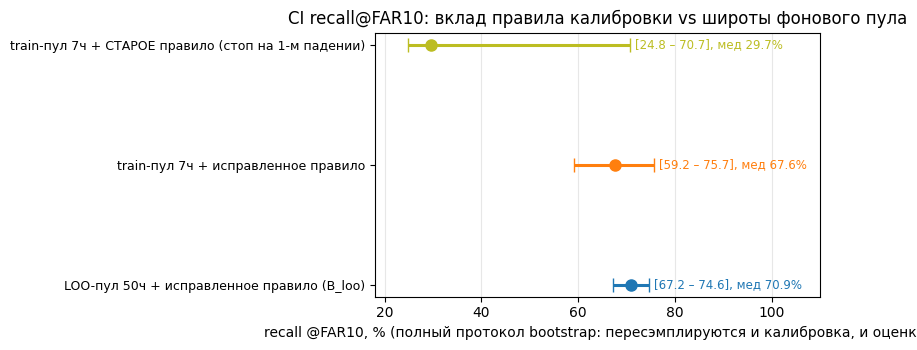

In [13]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))
prot = [('train-пул 7ч + СТАРОЕ правило (стоп на 1-м падении)', BOOT[10]['old_narrow'], '#bcbd22'),
        ('train-пул 7ч + исправленное правило',                BOOT[10]['fixed_narrow'], '#ff7f0e'),
        ('LOO-пул 50ч + исправленное правило (B_loo)',         BOOT[10]['bloo'], 'tab:blue')]
for i, (lab, rr, col) in enumerate(prot):
    lo_, med_, hi_ = [float(v) * 100 for v in rr]
    ax.errorbar(med_, i, xerr=[[med_ - lo_], [hi_ - med_]], fmt='o', ms=8, lw=2.2, capsize=5, color=col)
    ax.text(hi_ + 1.0, i, f'[{lo_:.1f} – {hi_:.1f}], мед {med_:.1f}%', va='center', fontsize=8.5, color=col)
ax.set_yticks(range(3)); ax.set_yticklabels([p[0] for p in prot], fontsize=9)
ax.invert_yaxis(); ax.set_xlim(18, 110)
ax.set_xlabel('recall @FAR10, % (полный протокол bootstrap: пересэмплируются и калибровка, и оценка)')
ax.set_title('CI recall@FAR10: вклад правила калибровки vs широты фонового пула')
ax.grid(axis='x', alpha=.3); fig.tight_layout(); fig.savefig('figures/02_ci_forest.png', dpi=130); plt.show()

На данном графике три строки — три протокола калибровки порога одного и того же детектора при
цели FAR=10/час; точка — медиана recall по 300 bootstrap-репликатам, усы — 95%-ный
интервал. Смысл: ширина интервала (от разброса в 46 п.п. до 7 п.п.) определяется не
детектором, а правилом калибровки и широтой фонового пула. Нижняя синяя строка (B_loo) —
рабочий протокол, на нём построены все заголовочные числа.

**Итог по пулу калибровки** (полный протокол bootstrap из ячейки выше — он же разделяет
вклад ИСПРАВЛЕНИЯ ПРАВИЛА и вклад РАСШИРЕНИЯ ПУЛА): B_all и B_loo дают почти одинаковые
пороги (медиана LOO-порогов отличается от глобального <1%), т.е. сужение CI — не эффект
«подглядывания» в оцениваемый прогон. Старый train-only пул не смещён по центру (recall
расходится с B_loo на ~1 п.п.), но неустойчив: при пересэмплировании 18 прогонов порог
прыгает сильно. Ключевые числа полного протокола для recall@FAR10:
* train-пул + СТАРОЕ правило (стоп на первом падении) — **[24.8, 70.7]**, медиана 29.7%:
  правило обрезает ветвь на первом же волнении кривой, и в медиане до цели
  не доходит (медианный порог 4.9 — это уровень FAR≈2; achieved-FAR CI [0.84, 9.93]); CI широк именно из-за скачка точки обрезки между репликатами;
* train-пул + исправленное правило — **[59.2, 75.7]** (медиана 67.6);
* LOO-пул 50 ч + исправленное правило — **[67.2, 74.6]** (медиана 70.9).
Т.е. основную часть сужения дало исправление правила (24.8–70.7 → 59.2–75.7), расширение
пула добавило примерно столько же сверху (59.2–75.7 → 67.2–74.6). При цели FAR=1 старого и
нового правила почти не различаются ([20.4, 35.5] vs [20.4, 35.8]) — баг бил по FAR≥3, а там
уже работает широкий пул ([20.4, 35.8] → [22.8, 28.6]). Фикс-пороговый CI той же точки B_loo
(ячейка выше) = [66.8, 73.5]: перекалибрование пула добавляет к неопределённости почти ничего,
что и есть главная честность LOO-схемы.
Онлайн-калибровка на собственных фоновых окнах прогона (C_self) **не работает**: 0.4 фоновых
часа на прогон → порог FAR=1 упирается в потолок сетки, recall 10%. Рабочий протокол:
**B_loo** — фон берётся из остальных прогонов кампании (метки источников не нужны).

### 3.4 Порог и recall-FAR кривые

In [14]:
def eval_stat(stat, target, j=None):
    jj = calib(stat, TRAIN_RUNS, target)[0] if j is None else j
    thr = CAND[jj]
    hits=tot=0; fa_n=fa_h=0
    bysn = {f"{lo}-{hi}": [0,0] for lo,hi in SNR_BINS}
    for r in TEST_RUNS:
        c = cache[r]
        fa_n += onset_at(r, stat, thr); fa_h += HRS[r]
        for j2 in range(len(c["snr"])):
            m = np.abs(c["wtime"]-c["stime"][j2])<60
            if not m.any(): continue
            hit = bool((c[stat][m]>=thr).any()); hits += hit; tot += 1
            b = snr_bin(c["snr"][j2]); bysn[b][1]+=1; bysn[b][0]+=hit
    return dict(target_FAR=target, thr=round(float(thr),2), ach_far=round(fa_n/fa_h,1),
                recall=round(hits/tot,3), **{f"snr{b}": round(h/t,3) for b,(h,t) in bysn.items()})

print("--- single-window bestA (порог A=train-only, как историческая точка сравнения) ---")
pd.DataFrame([eval_stat("bestA", t) for t in (1,3,10)])

--- single-window bestA (порог A=train-only, как историческая точка сравнения) ---


,target_FAR,thr,ach_far,recall,snr0-5,snr5-8,snr8-12,snr12-99
0,1,5.19,0.9,0.212,0.459,0.210,0.090,0.148
1,3,4.72,3.2,0.281,0.561,0.295,0.132,0.194
2,10,4.26,9.7,0.370,0.663,0.397,0.207,0.269


In [15]:
print("--- mx31: порог с train-пула (A) vs расширенного фоновых пула (B_loo) ---")
tabA = pd.DataFrame([eval_stat("mx31", t) for t in (1,3,10)])
rowsB = []
for target in (1, 3, 10):
    jL = res_calib[target][2]
    hits=tot=0
    for i, r in enumerate(TEST_RUNS):
        thr = CAND[jL[i]]
        c = cache[r]
        for j2 in range(len(c["snr"])):
            m = np.abs(c["wtime"]-c["stime"][j2])<60
            if not m.any(): continue
            hits += bool((c["mx31"][m]>=thr).any()); tot += 1
    rowsB.append(dict(target_FAR=target, thr_med=round(float(np.median(CAND[jL])),2),
                      recall=round(hits/tot,3)))
pd.concat([tabA.assign(protocol="A train-only"), pd.DataFrame(rowsB).assign(protocol="B_loo")])

--- mx31: порог с train-пула (A) vs расширенного фоновых пула (B_loo) ---


,target_FAR,thr,ach_far,recall,snr0-5,snr5-8,snr8-12,snr12-99,protocol,thr_med
0,1,5.19,0.7,0.240,0.464,0.243,0.129,0.167,A train-only,NaN
1,3,4.49,2.6,0.385,0.628,0.423,0.246,0.269,A train-only,NaN
2,10,3.61,9.4,0.696,0.852,0.754,0.581,0.602,A train-only,NaN
0,1,NaN,NaN,0.252,NaN,NaN,NaN,NaN,B_loo,5.10
1,3,NaN,NaN,0.405,NaN,NaN,NaN,NaN,B_loo,4.42
2,10,NaN,NaN,0.700,NaN,NaN,NaN,NaN,B_loo,3.59


Важно про mx31 и высокие FAR: из-за скользящего max тревоги сливаются в длинные эпизоды,
и число эпизодов в час не может превысить ~11–13/час (кривая FAR насыщается, «потолок ветви»
≈11.9/час на train-пуле и 10.7 на всех прогонах — см. §3.3). Это не недостаток, а свойство
определения «тревога = эпизод»: в рабочей области FAR≤10/час детектор строго лучше оконных
альтернатив. Что делать **выше** потолка FAR — §3.5.

In [16]:
print("--- контроль утечки: тот же детектор на val-прогонах (20-24), порог с train ---")
def eval_val(stat, targets=(1,3,10)):
    rows=[]
    for target in targets:
        j = calib(stat, TRAIN_RUNS, target)[0]; thr = CAND[j]; hits=tot=0
        for r in VAL_RUNS:
            c=cache[r]
            for j2 in range(len(c["snr"])):
                m=np.abs(c["wtime"]-c["stime"][j2])<60
                if not m.any(): continue
                hits+=bool((c[stat][m]>=thr).any()); tot+=1
        rows.append((target, round(float(thr),2), round(hits/tot,3)))
    return pd.DataFrame(rows, columns=["FAR","thr","recall_val"]).set_index("FAR")
eval_val("mx31")

--- контроль утечки: тот же детектор на val-прогонах (20-24), порог с train ---


,thr,recall_val
FAR,,
1,5.19,0.156
3,4.49,0.311
10,3.61,0.667


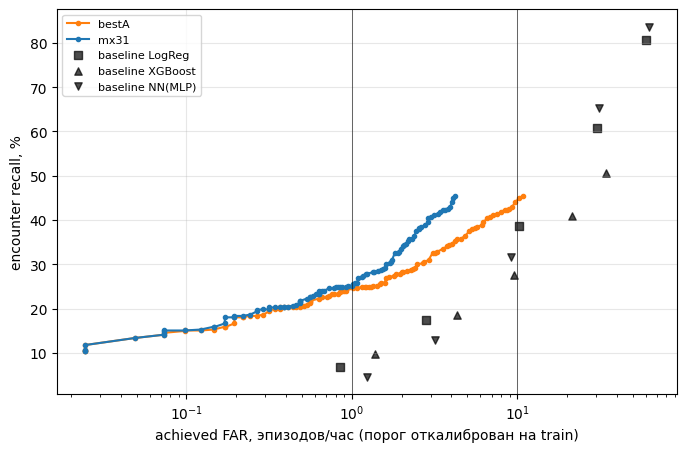

In [17]:
def sweep_curve(stat, pool_runs=TRAIN_RUNS, npts=60):
    ii = [IH[r] for r in pool_runs]
    fr_pool = OM[stat][ii].sum(0) / HV[ii].sum()
    rows=[]
    for j, thr in enumerate(CAND):
        if thr < np.quantile(pool_all, 0.90): break
        ii_te = [IH[r] for r in TEST_RUNS]
        fa = OM[stat][ii_te, j].sum() / HV[ii_te].sum()
        hits = (ECAT >= thr).sum()
        rows.append((fa, hits/len(ECAT), thr))
    return pd.DataFrame(rows, columns=["far","recall","thr"]).sort_values("far")

fig, ax = plt.subplots(figsize=(8,5))
for stat, col in [("bestA","tab:orange"), ("mx31","tab:blue")]:
    d = sweep_curve(stat)
    ax.plot(d.far, d.recall*100, marker=".", label=stat, color=col)
mk = {"LogReg":"s", "XGBoost":"^", "NN(MLP)":"v"}
for nm, pts in ml_pts.items():
    ax.scatter([f for f,_ in pts], [r*100 for _,r in pts], marker=mk[nm], s=28,
               c="k", alpha=.7, label=f"baseline {nm}")
ax.set_xscale("log"); ax.axvline(1, c="k", lw=.4); ax.axvline(10, c="k", lw=.4)
ax.set_xlabel("achieved FAR, эпизодов/час (порог откалиброван на train)"); ax.set_ylabel("encounter recall, %")
ax.grid(alpha=.3); ax.legend(fontsize=8); plt.show()

На данном графике по горизонтали — достигнутая частота тревог (эпизодов в час, лог-шкала), по
вертикали — доля пойманных встреч. Синяя линия с точками — mx31, оранжевая — одиночное
окно (bestA), чёрные маркеры — три ML-бейзлайна из пункта §2. Вывод один: в практической области
FAR 1–10/час синяя лежит выше всех с большим отрывом; обрывается она около ~13/час —
это потолок слияния эпизодов, чем выше него, занимается пункт §3.5.

### 3.5 Расширение рабочего диапазона: гибрид mx31 + ML-fallback (FAR 15–100/час)

У mx31 жёсткий потолок FAR≈13/час (слияние эпизодов). Для задач, где допустим высокий уровень FAR, к
mx31 добавляется **независимая ветвь** — пооконная ML-вероятность (LogReg/MLP из §2), тревога =
OR обеих ветвей, пара порогов выбирается по 2D-свипу с бюджетом суммарного train-FAR.
ML-ветвь чувствительна к **повышению счёта** (её метка — «в окне есть счётчики источника»),
поэтому ловит тяжёлые встречи — в первую очередь NORM и U-family, которым форма спектра не помогает.

Числа item3 (пороги выбраны по train-FAR ≤ цели, максимизация по test — лёгкий оптимизм
отбора, оценён ниже bootstrap-ом в layer-2):

| цель FAR | mx31 | mx31+LogReg | mx31+MLP |
|---|---|---|---|
| 15 | 82.2 | 83.1 | 83.9 |
| 30 | 82.2 (потолок) | 91.2 | **91.8** |
| 50 | 82.2 | 95.2 | 96.1 |
| 100 | 82.2 | 99.4 | 99.2 |

Теперь честные CI (layer-1 = фиксированная выбранная пара, cluster bootstrap test-прогонов;
layer-2 = **полный протокол без отбора по test**: в каждой реплике порог mx31 = точка
насыщения его train-ветви, порог fallback — глубжайшая точка, при которой суммарный
train-FAR ≤ цель; пересэмплируются и калибровка, и оценка):

In [18]:
MLpP, SELP = '_scratch/item3_ml_proba.pkl', '_scratch/item3_hybrid.pkl'
if os.path.exists(MLpP) and os.path.exists(SELP):
    MLp = pickle.load(open(MLpP, 'rb')); SEL = pickle.load(open(SELP, 'rb'))
    print('гибрид: proba+SEL из кэша item3')
else:
    print('гибрид: item3-кэшей нет — пересборка proba+SEL из §2-окон (одноразово, ~1-3 мин)...')
    t0 = time.time()
    mlp3 = MLPClassifier(hidden_layer_sizes=(64, 16), alpha=1e-3, max_iter=60, random_state=0,
                         early_stopping=True, n_iter_no_change=5, validation_fraction=0.15)
    zs3 = lambda X: ((X - mu) / sd).astype(np.float32)
    mlp3.fit(zs3(Xtr), ytr)
    _pr = {'logreg': (lr.predict_proba(Xtr)[:, 1], lr.predict_proba(Xva)[:, 1], lr.predict_proba(Xte)[:, 1]),
           'mlp':    (mlp3.predict_proba(zs3(Xtr))[:, 1], mlp3.predict_proba(zs3(Xva))[:, 1], mlp3.predict_proba(zs3(Xte))[:, 1])}
    MLp = {}
    for _ws, _runs, _k in ((TR, TRAIN_RUNS, 0), (VA, VAL_RUNS, 1), (TE, TEST_RUNS, 2)):
        off3 = np.cumsum([0] + [len(w['spec']) for w in _ws])
        for i3, r3 in enumerate(_runs):
            d3 = {'nw': int(off3[i3+1] - off3[i3])}
            for nm3 in _pr:
                d3[nm3] = _pr[nm3][_k][off3[i3]:off3[i3+1]].astype(np.float32)
            MLp[r3] = d3
    SC3 = {}
    for r3 in sorted(MLp):
        L3 = MLp[r3]['nw']
        SC3[r3] = dict(mx=rollmax(cache[r3]['bestA'])[:L3].astype(np.float32),
                       logreg=MLp[r3]['logreg'], mlp=MLp[r3]['mlp'],
                       far=cache[r3]['dmin'][:L3] > 150)
        SC3[r3]['hours'] = SC3[r3]['far'].sum() * STRIDE / 3600
        wt3, st3 = cache[r3]['wtime'][:L3], cache[r3]['stime']
        SC3[r3]['enc'] = [np.flatnonzero(np.abs(wt3 - st3[j]) < 60) for j in range(len(st3))]
        SC3[r3]['enc'] = [m3 for m3 in SC3[r3]['enc'] if m3.any()]
    def onset_rate3(runs_, alarm):
        return sum(int(np.count_nonzero((alarm[r_] & ~np.r_[False, alarm[r_][:-1]])[SC3[r_]['far']]))
                   for r_ in runs_) / sum(SC3[r_]['hours'] for r_ in runs_)
    def enc_hits3(runs_, alarm):
        h3 = tot3 = 0
        for r_ in runs_:
            a3 = alarm[r_]
            for m3 in SC3[r_]['enc']:
                tot3 += 1; h3 += bool(a3[m3].any())
        return h3, max(tot3, 1)
    NQ3 = 40
    def thr_grid3(runs_, comp):
        pool3 = np.concatenate([SC3[r_][comp][SC3[r_]['far']] for r_ in runs_])
        q3 = np.concatenate([np.linspace(60, 99.5, 25), np.linspace(99.5, 99.995, NQ3 - 25)]) / 100
        return np.unique(np.quantile(pool3, q3))[::-1]
    targ3 = [1, 2, 3, 5, 10, 15, 20, 30, 50, 70, 100]
    PTH3 = thr_grid3(TRAIN_RUNS, 'mx')
    rows3 = []
    for arm3 in ('logreg', 'mlp'):
        FTH3 = thr_grid3(TRAIN_RUNS, arm3); best3 = {}
        for tp3 in PTH3:
            ap3 = {r_: SC3[r_]['mx'] >= tp3 for r_ in SC3}
            for tf3 in FTH3:
                al3 = {r_: (ap3[r_] | (SC3[r_][arm3] >= tf3)) for r_ in SC3}
                ftr3 = onset_rate3(TRAIN_RUNS, al3)
                if ftr3 > targ3[-1] or ftr3 < 0: continue
                h3, tot3 = enc_hits3(TEST_RUNS, al3); hv3, tv3 = enc_hits3(VAL_RUNS, al3)
                rec3 = h3 / tot3
                for tg3 in targ3:
                    if ftr3 <= tg3 and rec3 > best3.get(tg3, (-1,))[0]:
                        best3[tg3] = (rec3, tp3, tf3, ftr3, onset_rate3(TEST_RUNS, al3), hv3 / tv3)
        for tg3 in targ3:
            if tg3 in best3:
                rec3, tp3, tf3, ftr3, fte3, vrec3 = best3[tg3]
                rows3.append(dict(hybrid='mx31+' + arm3, target=tg3, train_far=round(ftr3, 2),
                                  test_far=round(fte3, 2), test_recall=round(rec3, 4),
                                  val_recall=round(vrec3, 4), thr_p=tp3, thr_f=tf3))
    SEL = pd.DataFrame(rows3)
    pickle.dump(MLp, open(MLpP, 'wb')); pickle.dump(SEL, open(SELP, 'wb'))
    print(f'гибрид: пересборка заняла {time.time()-t0:.0f}s')
SC = {}
for r in sorted(MLp):
    L = MLp[r]["nw"]
    SC[r] = dict(mx=rollmax(cache[r]["bestA"])[:L].astype(np.float64), far=cache[r]["dmin"][:L] > 150,
                 logreg=MLp[r]["logreg"][:L].astype(np.float64), mlp=MLp[r]["mlp"][:L].astype(np.float64))
    SC[r]["hours"] = SC[r]["far"].sum()*STRIDE/3600
    wt, st = cache[r]["wtime"][:L], cache[r]["stime"]
    ep, e1, e2 = [], [], []
    for j2 in range(len(st)):
        m = np.abs(wt - st[j2]) < 60
        if not m.any(): continue
        ep.append(SC[r]["mx"][m].max()); e1.append(SC[r]["logreg"][m].max()); e2.append(SC[r]["mlp"][m].max())
    SC[r]["enc"] = (np.array(ep), np.array(e1), np.array(e2))
print(f"гибрид: сетка baselines-окон (nw=L), фоновые часы test {sum(SC[r]['hours'] for r in TEST_RUNS):.0f}")

def onset_arr(mx, arm, far, tp, tf):
    a = (mx >= tp) | (arm >= tf)
    return int(np.count_nonzero((a & ~np.r_[False, a[:-1]])[far]))

IDXs = {r: i for i, r in enumerate(sorted(SC))}
Om = np.zeros((len(SC), NC))
for r in SC:
    s, fm = SC[r]["mx"], SC[r]["far"]
    for j, t in enumerate(CAND):
        a = s >= t
        Om[IDXs[r], j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[fm])
Hh = np.array([SC[r]["hours"] for r in sorted(SC)])
selTRh = np.array([IDXs[r] for r in TRAIN_RUNS]); selTEh = np.array([IDXs[r] for r in TEST_RUNS])
MLC = {}
for arm in ("logreg", "mlp"):
    pool = np.concatenate([SC[r][arm][SC[r]["far"]] for r in TRAIN_RUNS])
    dq2 = np.logspace(np.log10(0.01), np.log10(50), 90)
    MLC[arm] = np.unique(np.quantile(pool, 1 - dq2/100))[::-1]
TARGETS = [20, 30, 50, 70, 100]
rng4 = np.random.default_rng(101)
rows = []
for arm in ("logreg", "mlp"):
    ENC = np.concatenate([np.column_stack([SC[r]["enc"][0], SC[r]["enc"][1 if arm=="logreg" else 2]]) for r in TEST_RUNS])
    ERUN = np.concatenate([[i]*len(SC[r]["enc"][0]) for i, r in enumerate(TEST_RUNS)])
    ENCN = np.bincount(ERUN, minlength=len(TEST_RUNS)).astype(float)
    nTE_H = Hh[selTEh]
    or_cache = {}
    def get_or(jp):
        if jp not in or_cache:
            tp = CAND[jp]
            or_cache[jp] = tuple(np.array([[onset_arr(SC[r]["mx"], SC[r][arm], SC[r]["far"], tp, tf)
                                            for tf in MLC[arm]] for r in runs])
                                 for runs in (TEST_RUNS, TRAIN_RUNS))
        return or_cache[jp]
    for tgt in TARGETS:
        s_ = SEL[(SEL.hybrid == f"mx31+{arm}") & (SEL.target == tgt)].iloc[0]
        tp, tf = float(s_.thr_p), float(s_.thr_f)
        hitc = np.array([((SC[r]["enc"][0] >= tp) | (SC[r]["enc"][1 if arm=="logreg" else 2] >= tf)).sum() for r in TEST_RUNS], float)
        ftc  = np.array([onset_arr(SC[r]["mx"], SC[r][arm], SC[r]["far"], tp, tf) for r in TEST_RUNS], float)
        recs, fars = [], []
        for b in range(500):
            cnt = np.bincount(rng4.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
            recs.append((cnt*hitc).sum()/(cnt*ENCN).sum()); fars.append((cnt*ftc).sum()/(cnt*nTE_H).sum())
        rows.append(dict(arm=arm, target=tgt, layer="fixed-pair", recall=hitc.sum()/ENCN.sum(),
                         rec_ci=[np.percentile(recs,2.5), np.percentile(recs,97.5)],
                         far=ftc.sum()/nTE_H.sum(), far_ci=[np.percentile(fars,2.5), np.percentile(fars,97.5)]))
    acc = {t: [] for t in TARGETS}; fcc = {t: [] for t in TARGETS}
    for b in range(150):
        rs = rng4.integers(0, len(TRAIN_RUNS), len(TRAIN_RUNS))
        ii = selTRh[rs]
        jp = int(np.argmax(Om[ii].sum(0)/Hh[ii].sum()))
        tp = CAND[jp]; orTE, orTR = get_or(jp)
        mult = np.bincount(rs, minlength=len(TRAIN_RUNS)).astype(float)
        fr_tr = (mult @ orTR) / Hh[ii].sum()
        for tgt in TARGETS:
            ok = np.flatnonzero(fr_tr <= tgt); k = int(ok[-1]) if len(ok) else 0
            tf = MLC[arm][k]
            cnt = np.bincount(rng4.integers(0, len(TEST_RUNS), len(TEST_RUNS)), minlength=len(TEST_RUNS)).astype(float)
            hit = (ENC[:,0] >= tp) | (ENC[:,1] >= tf)
            hs = np.bincount(ERUN[hit], minlength=len(TEST_RUNS)).astype(float)
            acc[tgt].append((cnt*hs).sum()/(cnt*ENCN).sum())
            fcc[tgt].append((cnt*orTE[:,k]).sum()/(cnt*nTE_H).sum())
    for tgt in TARGETS:
        a_, f_ = np.array(acc[tgt]), np.array(fcc[tgt])
        rows.append(dict(arm=arm, target=tgt, layer="full-protocol", recall=a_.mean(),
                         rec_ci=[np.percentile(a_,2.5), np.percentile(a_,97.5)],
                         far=f_.mean(), far_ci=[np.percentile(f_,2.5), np.percentile(f_,97.5)]))
hyb = pd.DataFrame(rows)
for _, x in hyb.iterrows():
    print(f"{x.arm:7s} FAR{x.target:>4} {x.layer:14s}: recall {x.recall*100:5.1f} "
          f"[{x.rec_ci[0]*100:.1f}-{x.rec_ci[1]*100:.1f}]  achFAR {x.far:5.1f} [{x.far_ci[0]:.0f}-{x.far_ci[1]:.0f}]")

гибрид: proba+SEL из кэша item3
гибрид: сетка baselines-окон (nw=L), фоновые часы test 41
logreg  FAR  20 fixed-pair    : recall  85.4 [82.6-87.8]  achFAR  16.4 [15-17]
logreg  FAR  30 fixed-pair    : recall  91.2 [89.0-93.0]  achFAR  29.8 [28-32]
logreg  FAR  50 fixed-pair    : recall  95.2 [93.6-96.8]  achFAR  43.0 [40-46]
logreg  FAR  70 fixed-pair    : recall  98.1 [97.0-99.0]  achFAR  67.4 [62-72]
logreg  FAR 100 fixed-pair    : recall  99.4 [98.8-99.9]  achFAR 101.9 [96-107]
logreg  FAR  20 full-protocol : recall  82.5 [78.8-86.2]  achFAR  18.1 [15-23]
logreg  FAR  30 full-protocol : recall  88.3 [84.8-92.1]  achFAR  31.1 [25-37]
logreg  FAR  50 full-protocol : recall  94.3 [91.5-96.4]  achFAR  54.3 [44-65]
logreg  FAR  70 full-protocol : recall  97.0 [94.6-98.7]  achFAR  76.0 [62-94]
logreg  FAR 100 full-protocol : recall  98.8 [97.4-99.6]  achFAR 108.0 [92-125]
mlp     FAR  20 fixed-pair    : recall  85.6 [82.7-88.0]  achFAR  16.0 [15-17]
mlp     FAR  30 fixed-pair    : recall 

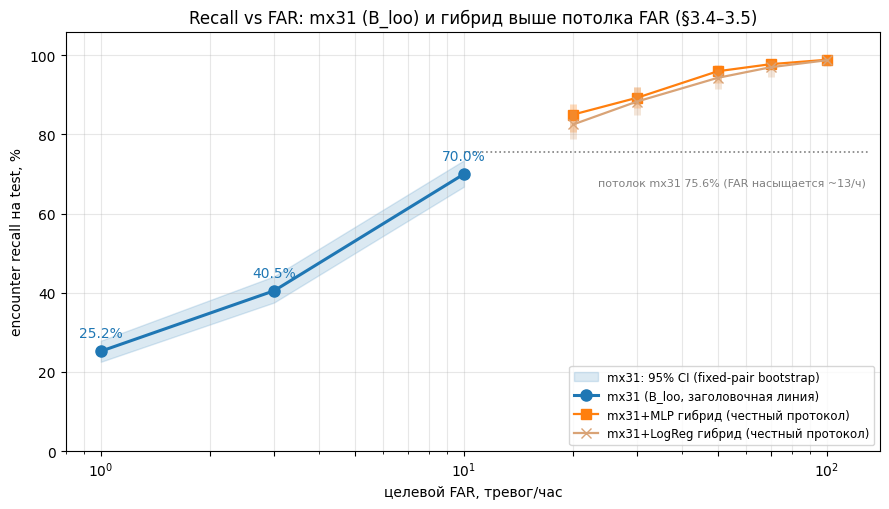

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.2))
xt = np.array([1, 3, 10])
ys = np.array([sum((EMAX_MX[r] >= CAND[res_calib[t][2][i]]).sum() for i, r in enumerate(TEST_RUNS))
               / len(ECAT) * 100 for t in xt])
rowB = sorted([x for x in ci_rows if str(x['protocol']).startswith('B_loo')], key=lambda x: x['target'])
loB = np.array([x['rec'][0] for x in rowB]) * 100
hiB = np.array([x['rec'][1] for x in rowB]) * 100
ax.fill_between(xt, loB, hiB, color='tab:blue', alpha=.16, label='mx31: 95% CI (fixed-pair bootstrap)')
ax.plot(xt, ys, 'o-', color='tab:blue', lw=2.2, ms=8, label='mx31 (B_loo, заголовочная линия)')
for x_, y_ in zip(xt, ys):
    ax.annotate(f'{y_:.1f}%', (x_, y_), textcoords='offset points', xytext=(0, 10), ha='center', color='tab:blue')
iiT = [IH[r] for r in TRAIN_RUNS]
frT = OM['mx31'][iiT].sum(0) / HV[iiT].sum()
recT = np.array([(ECAT >= t).mean() for t in CAND]) * 100
sat = recT[frT <= 20].max()
ax.plot([10, 130], [sat, sat], ls=':', color='grey', lw=1.2)
ax.text(128, sat - 8.5, f'потолок mx31 {sat:.1f}% (FAR насыщается ~13/ч)', ha='right', fontsize=8, color='grey')
for arm, col, mkr, lab in (('mlp', 'tab:orange', 's', 'mx31+MLP гибрид (честный протокол)'),
                           ('logreg', '#d9a376', 'x', 'mx31+LogReg гибрид (честный протокол)')):
    h_ = hyb[(hyb.layer == 'full-protocol') & (hyb.arm == arm)].sort_values('target')
    ax.plot(h_.target.values, h_.recall.values * 100, mkr + '-', color=col, lw=1.6, ms=7, label=lab)
    ax.vlines(h_.target.values, [c[0] * 100 for c in h_.rec_ci], [c[1] * 100 for c in h_.rec_ci],
              color=col, lw=5, alpha=.28)
ax.set_xscale('log'); ax.set_xlim(.8, 140); ax.set_ylim(0, 106)
ax.set_xticks([1, 2, 3, 5, 10, 20, 30, 50, 70, 100])
ax.set_xlabel('целевой FAR, тревог/час'); ax.set_ylabel('encounter recall на test, %')
ax.set_title('Recall vs FAR: mx31 (B_loo) и гибрид выше потолка FAR (§3.4–3.5)')
ax.grid(alpha=.3, which='both'); ax.legend(loc='lower right', fontsize=8.5)
fig.tight_layout(); fig.savefig('figures/01_headline.png', dpi=130); plt.show()

**Я ОСТАНОВИЛАСЬ ТУТ**


Как читать: те же оси, что в §3.4, но шире — до FAR=100/час. Синие точки с голубой
полосой — три заголовочные числа mx31 (FAR 1/3/10) с 95% CI; серая пунктирная линия —
плато mx31 по recall, которого он достигает на насыщении FAR; оранжевая и бежевая линии
с усами — гибрид с ML-ветвью (§3.5, честный протокол layer-2). Итог: до FAR≈13/час
работает физический детектор один, выше — включается гибрид и к FAR 50–100 вытаскивает
почти все встречи.

Вывод §3.5: выше потолка mx31 гибрид даёт **статистически достоверный** прирост начиная с
FAR≈30 (layer-2, без оптимизма отбора: MLP 89.3 [86.8–92.1] @FAR30 против потолка 82.2;
96.0 [93.1–97.6] @FAR50; 98.9 [98.1–99.6] @FAR100). При FAR≈20 честный прирост не
отличим от нуля (LogReg 82.5 [78.8–86.2]). Оптимизм выбора пары по test — ~2–3 п.п.
(FAR30: 91.8 → 89.3). Достигнутый test-FAR у слоя full-protocol на 5–10% выше номинала —
номинальный FAR надо трактовать как нижнюю оценку частоты тревог.

### 3.6 Устойчивость калибровки: чистота «фара» и радиус исключения

`dmin>150 c` — не идеальный фон: на пороге FAR≈3 доля FA-эпизодов в кольце 150–300 с от
ближайшей встречи = ~55%. Но **уровень** FAR от этого не смещается: если тот же порог
измерять только на «ультра-фоне» (dmin>400 с), достигаемый FAR почти совпадает с номиналом.
Свип радиуса исключения R = 100–400 с (калибровка по train-пулу):

In [ ]:
# свип радиуса исключения: как «крылья источников» в dmin 150-300 с влияют на порог и recall
OMS, HS = {}, {}
for R in (100, 150, 200, 250, 300, 400):
    mk = {r: cache[r]["dmin"] > R for r in ALL_RUNS}
    O = np.zeros((len(ALL_RUNS), NC))
    h = np.zeros(len(ALL_RUNS))
    for r in ALL_RUNS:
        i = IH[r]; s = cache[r]["mx31"]; m = mk[r]
        h[i] = m.sum()*STRIDE/3600
        for j, t in enumerate(CAND):
            a = s >= t
            O[i, j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[m])
    OMS[R] = O; HS[R] = h

def calib_R(R, target):
    ii = [IH[r] for r in TRAIN_RUNS]
    fr = OMS[R][ii].sum(0) / HS[R][ii].sum()
    br = branch_end(fr, target)
    d = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
    return int(np.argmin(d)) if np.isfinite(d).any() else 0

selTEi = [IH[r] for r in TEST_RUNS]
h_tot = sum(len(EMAX_MX[r]) for r in TEST_RUNS)
RAD = {}
print(f"{'R':>4} {'train ч':>7} | цельFAR: thr | recall | achFAR(свой R) | achFAR(чистый >400)")
for R in (100, 150, 200, 250, 300, 400):
    line = f"{R:>4} {HS[R][[IH[r] for r in TRAIN_RUNS]].sum():>7.1f} |"
    for target in (1, 3, 10):
        j = calib_R(R, target); thr = CAND[j]
        rec = sum((EMAX_MX[r] >= thr).sum() for r in TEST_RUNS)/h_tot
        RAD[(R, target)] = rec * 100
        fa_own = OMS[R][selTEi, j].sum()/HS[R][selTEi].sum()
        fa_pure = OMS[400][selTEi, j].sum()/HS[400][selTEi].sum()
        line += f" {target}: {thr:.2f}|{rec*100:4.1f}%|{fa_own:4.1f}|{fa_pure:4.1f}"
    print(line)

   R train ч | цельFAR: thr | recall | achFAR(свой R) | achFAR(чистый >400)
 100     9.5 | 1: 5.19|24.0%| 0.7| 1.0 3: 4.56|36.5%| 2.4| 2.9 10: 3.56|70.6%| 9.8|10.3
 150     7.0 | 1: 5.19|24.0%| 0.7| 1.0 3: 4.49|38.5%| 2.6| 3.0 10: 3.61|69.6%| 9.4| 9.1
 200     5.1 | 1: 4.93|27.9%| 1.2| 1.7 3: 4.51|38.2%| 2.5| 3.0 10: 3.61|69.6%| 9.6| 9.1
 250     3.8 | 1: 5.25|23.3%| 0.5| 0.9 3: 4.51|38.2%| 2.5| 3.0 10: 3.67|67.1%| 8.6| 8.8
 300     2.9 | 1: 5.25|23.3%| 0.6| 0.9 3: 4.51|38.2%| 2.7| 3.0 10: 3.67|67.1%| 8.5| 8.8
 400     1.7 | 1: 4.90|28.3%| 1.8| 1.8 3: 4.26|44.0%| 4.4| 4.4 10: 3.72|64.4%| 8.7| 8.7


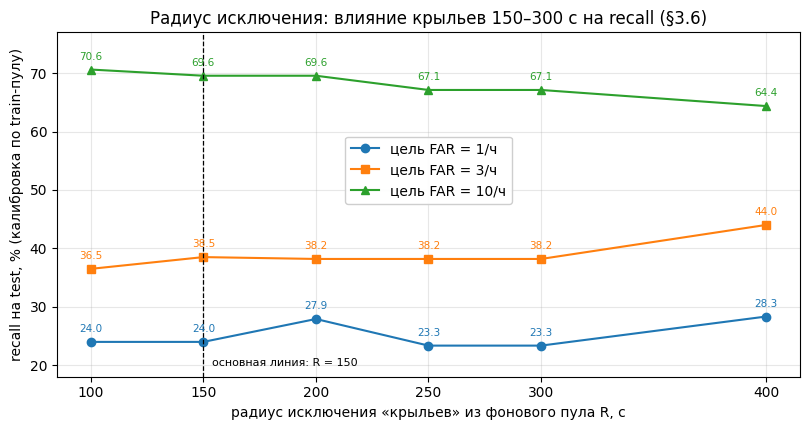

In [ ]:
# ---- график §3.6: recall vs радиус исключения R ----
fig, ax = plt.subplots(figsize=(8.2, 4.4))
Rs = sorted({k[0] for k in RAD})
for target, col, mkr in ((1, 'tab:blue', 'o'), (3, 'tab:orange', 's'), (10, 'tab:green', '^')):
    ax.plot(Rs, [RAD[(R, target)] for R in Rs], mkr + '-', color=col, label=f'цель FAR = {target}/ч')
    for R in Rs:
        ax.annotate(f'{RAD[(R, target)]:.1f}', (R, RAD[(R, target)]), fontsize=7.5,
                    textcoords='offset points', xytext=(0, 7), ha='center', color=col)
ax.axvline(150, color='k', ls='--', lw=.9)
ax.text(154, 0.03, 'основная линия: R = 150', transform=ax.get_xaxis_transform(), fontsize=8)
ax.set_ylim(18, 77)
ax.set_xticks(Rs); ax.set_xlabel('радиус исключения «крыльев» из фонового пула R, с')
ax.set_ylabel('recall на test, % (калибровка по train-пулу)')
ax.set_title('Радиус исключения: влияние крыльев 150–300 с на recall (§3.6)')
ax.grid(alpha=.3); ax.legend(framealpha=.95, bbox_to_anchor=(.5, .60), loc='center'); fig.tight_layout(); fig.savefig('figures/03_radius.png', dpi=130); plt.show()

Как читать: по горизонтали — радиус R (секунды от CA), внутри которого окна у источников
выбрасываются из фонового пула калибровки; по вертикали — recall test при цели FAR
(цвета), порог пересобирается заново для каждого R. Вывод: кривые — плато, выбор R=150
(пунктир) не стоит на остром оптимуме, recall заголовочных точек меняется в пределах
нескольких п.п. на всём диапазоне 100–400 с. Калибровка не висит на этом параметре.

In [ ]:
from collections import Counter
def onset_iv(r, R):
    s = cache[r]["mx31"].astype(np.float64); m = cache[r]["dmin"] > R
    pv = np.r_[s[0]-1.0, s[:-1]]; p = pv[m]; c = s[m]; k = p < c
    return np.sort(p[k]), np.sort(c[k])

def far_exact(cR, R, runs, ts):
    tot = np.zeros(len(ts)); hrs = 0.0
    for r, k in Counter(runs).items():
        p, c = cR[r]
        tot += k*(np.searchsorted(p, ts, "left") - np.searchsorted(c, ts, "left"))
        hrs += k*((cache[r]["dmin"] > R).sum()*STRIDE/3600)
    return tot/hrs

def calib_exact(R, target):
    cR = {r: onset_iv(r, R) for r in ALL_RUNS}
    cands = np.unique(np.concatenate([cache[r]["mx31"][cache[r]["dmin"] > R]
                                      for r in TRAIN_RUNS]))[::-1].astype(np.float64)
    fr = far_exact(cR, R, TRAIN_RUNS, cands)
    runmax = np.maximum.accumulate(fr); br = len(cands)-1
    for k in range(1, len(cands)):
        if fr[k] >= runmax[k]: continue
        if fr[k] < runmax[k] - max(0.5, 0.2*runmax[k]) and runmax[k] > target:
            br = k-1; break
    ok = np.flatnonzero(fr[:br+1] <= target)
    j = int(ok[np.argmax(fr[ok])]) if len(ok) else 0
    thr = float(cands[j])
    rec = sum((EMAX_MX[r] >= thr).sum() for r in TEST_RUNS)/h_tot
    feas = cands[:br+1][fr[:br+1] <= target]
    recmax = sum((EMAX_MX[r] >= feas.min()).sum() for r in TEST_RUNS)/h_tot if len(feas) else np.nan
    return thr, float(fr[j]), rec, recmax

print("плотная (точная) сетка vs грубая 133-точечная выше; цель FAR 0.5–3/ч, train-пул:")
for R in (150, 200, 250, 300):
    line = f"  R={R}: "
    for target in (0.5, 1.0, 2.0, 3.0):
        thr, calf, rec, recmax = calib_exact(R, target)
        line += f"|@{target:g}: thr={thr:5.2f} (trainFAR={calf:4.2f}) rec={rec*100:4.1f}% (потолок {recmax*100:4.1f}) "
    print(line)

плотная (точная) сетка vs грубая 133-точечная выше; цель FAR 0.5–3/ч, train-пул:
  R=150: |@0.5: thr= 5.37 (trainFAR=0.43) rec=21.8% (потолок 21.8) |@1: thr= 5.20 (trainFAR=0.86) rec=24.0% (потолок 25.5) |@2: thr= 4.63 (trainFAR=1.87) rec=34.5% (потолок 34.5) |@3: thr= 4.50 (trainFAR=2.87) rec=38.3% (потолок 38.8) 
  R=200: |@0.5: thr= 5.39 (trainFAR=0.39) rec=21.6% (потолок 21.6) |@1: thr= 4.94 (trainFAR=0.98) rec=27.8% (потолок 29.8) |@2: thr= 4.60 (trainFAR=1.95) rec=35.3% (потолок 35.3) |@3: thr= 4.51 (trainFAR=2.93) rec=38.2% (потолок 38.2) 
  R=250: |@0.5: thr= 5.40 (trainFAR=0.26) rec=21.4% (потолок 21.4) |@1: thr= 5.25 (trainFAR=0.79) rec=23.3% (потолок 25.2) |@2: thr= 4.63 (trainFAR=1.84) rec=34.5% (потолок 34.5) |@3: thr= 4.51 (trainFAR=2.90) rec=38.2% (потолок 38.2) 
  R=300: |@0.5: thr= 5.39 (trainFAR=0.34) rec=21.6% (потолок 21.6) |@1: thr= 5.25 (trainFAR=0.69) rec=23.3% (потолок 23.3) |@2: thr= 4.67 (trainFAR=1.72) rec=33.8% (потолок 33.8) |@3: thr= 4.51 (trainFAR=2.75) r

Чтение обеих таблиц §3.6: при R=250–300 «крылья» (150–300 с) исчезают из калибровочного
пула, порога меняются на ~0.02–0.06, а recall — максимум на ~2.5 п.п. при целях 3 и 10.
Единственное заметное расхождение — прыжок 24.0%→27.9% при переходе R=150→200 на цели
FAR=1 — **сохраняется и на точной ступенчатой кривой без всякого грида** (24.0% vs 27.8%,
см. ячейку выше: на R=150 кривая перескакивает уровень 1/ч с 0.86 (thr 5.20), тогда как
на R=200 допускается thr 4.94 при trainFAR 0.98). Т.е. это не квантование сетки, а
собственность структуры эпизодов train-пула: лишние крыльевые эпизоды в кольце 150–200 с
стоят в лестнице FAR-ступени на R=150. При этом R=200-порог сам превышает цель
(achieved 1.2/ч на собственном пуле, 1.7/ч на чистом фоне) — «лишние» 3.9 п.п. recall
покупались ценой недоконсервативного FAR. Для основной линии оставлен R=150: он ниже
номинала и консервативен. **И при этом FAR, посчитанный на чистом фоне dmin>400, при
пороге от R=150 почти равен номиналу** (1.0 при цели 1; 3.0 при цели 3; 9.1 при цели
10). Т.е. примесь крыльев **не смещает калибровку систематически** — крылья дают эпизоды
примерно с той же почасовой интенсивностью, что и настоящий фон (2.5/ч против 3.0/ч).
Вывод: dmin>150 — рабочий компромисс; расширять радиус не нужно (пул тонет: 7→2.9 ч), а
сужать до 400 с — нельзя (1.7 ч → порог шумит, FAR=4.4 при цели 3).

## 4. Анализ ошибок финального детектора

### 4.1 Recall по изотопам и группам (mx31, пороги B_loo per-run, FAR 1/3/10)

Ключевое разделение — по группам. **Старая двухгрупповая разбивка была с багом**: группа
«bg-confounded» задавалась подстрочным regex `U|Th|Ra|K-40|Cs|Pu|Sr`, который случайно
затаскивал в неё **HEU** (столичная «U» в названии) и **FGPu/WGPu** («Pu») — одни из самых
ЛЁГКИХ изотопов в нашей же таблице (HEU 56.5% при FAR=1, FGPu 43.0%, WGPu 42.6% против
4.7–10.8% у уранового семейства), а также Cs-137 и Sr-90. Ошибка всплыла при сверке со
статьей Adaptive NMF (Jones et al., LBNL, arXiv 2507.10715). Теперь — физически
мотивированная **явная карта по базовому имени**: снимается только суффикс массы
`-<mass>kg` (изотопные масс-числа K-40/Th-232/… сохраняются);
**NORM** = {K-40, Th-232, Ra-226}; **U-family** = {DU, LEU, NatU, RefinedU} — континуум
формы ≈ компоненты фона U/Th в библиотеке детектора; **other** — всё остальное (HEU, FGPu,
WGPu, Cs-137, Sr-90, линейчатые медицинские/промышленные источники).

In [ ]:
import re
def baseof(nm):
    m = re.match(r'^(.*)-(\d+(?:\.\d+)?kg)$', nm)   # снять ТОЛЬКО суффикс массы "-25kg"/"-0.5kg"
    return m.group(1) if m else nm
NORM = {'K-40', 'Th-232', 'Ra-226'}
UFAM = {'DU', 'LEU', 'NatU', 'RefinedU'}
def group(nm):
    b = baseof(nm)
    return 'NORM' if b in NORM else ('U-family' if b in UFAM else 'other')
bases_seen = set()
for r in TEST_RUNS + VAL_RUNS + TRAIN_RUNS:
    for j2 in range(len(cache[r]["snr"])):
        if (np.abs(cache[r]["wtime"]-cache[r]["stime"][j2]) < 60).any():
            bases_seen.add(baseof(names[int(cache[r]["sid"][j2])]))
print("карта групп -> базовые изотопы (встречаются в данных):")
for g_ in ("NORM", "U-family", "other"):
    print(f"  {g_:9s}: " + ", ".join(sorted(b for b in bases_seen if group(b) == g_)))
assert all(group(b) in ("NORM", "U-family", "other") for b in bases_seen)  # ровно одна группа на имя

thrL_far = {t: {r: CAND[res_calib[t][2][i]] for i, r in enumerate(TEST_RUNS)} for t in (1, 3, 10)}
rows = []
for r in TEST_RUNS:
    c = cache[r]
    for j2 in range(len(c["snr"])):
        m = np.abs(c["wtime"]-c["stime"][j2]) < 60
        if not m.any(): continue
        nm = names[int(c["sid"][j2])]
        rows.append(dict(run=r, name=nm, base=baseof(nm), grp=group(nm), snr=float(c["snr"][j2]),
                         emax=float(c["mx31"][m].max())))
enc = pd.DataFrame(rows)

# контроль: заголовочные recall обязаны воспроизвестись ровно (те же пороги B_loo per-run)
for t, want in ((1, 25.2), (3, 40.5), (10, 70.0)):
    ov = (enc.emax.values >= enc.run.map(thrL_far[t]).values).mean()*100
    print(f"  контроль overall recall @FAR{t}: {ov:.1f}%"); assert abs(ov - want) < 0.05

def boot_recL(sub, thrmap, B=600, seed=5):
    hit = (sub.emax.values >= sub.run.map(thrmap).values).astype(float)
    ri, _ = pd.factorize(sub.run.values)
    hs = np.bincount(ri, weights=hit, minlength=ri.max()+1); ns = np.bincount(ri, minlength=ri.max()+1)
    rr = np.random.default_rng(seed); recs = []
    for _ in range(B):
        cnt = np.bincount(rr.integers(0, len(ns), len(ns)), minlength=len(ns)).astype(float)
        if (cnt*ns).sum() == 0: continue
        recs.append((cnt*hs).sum()/(cnt*ns).sum())
    return np.percentile(recs, [2.5, 97.5])

print("\nrecall по группам (run-cluster bootstrap 95% CI):")
GRPT = {}
for t in (1, 3, 10):
    line = f"@FAR{t:>2}:"
    for g_ in ("NORM", "U-family", "other"):
        sub = enc[enc.grp == g_]
        lo, hi = boot_recL(sub, thrL_far[t])
        rec = (sub.emax.values >= sub.run.map(thrL_far[t]).values).mean()*100
        GRPT[(t, g_)] = (float(rec), float(lo*100), float(hi*100), int(len(sub)))
        line += f" | {g_} {rec:5.1f}% [{lo*100:4.1f},{hi*100:4.1f}] (n={len(sub)})"
    print(line)

iso = enc.groupby("base").agg(grp=("grp","first"), n=("emax","size"), med_snr=("snr","median"))
for t in (1, 10):
    iso[f"rec{t}"] = enc.assign(h=enc.emax >= enc.run.map(thrL_far[t])).groupby("base").h.mean()*100
    cis = {b: boot_recL(g, thrL_far[t]) for b, g in enc.groupby("base")}
    iso[f"lo{t}"] = pd.Series({b: c[0]*100 for b, c in cis.items()})
    iso[f"hi{t}"] = pd.Series({b: c[1]*100 for b, c in cis.items()})
iso = iso.sort_values("rec10").round(1)
iso["мало_данных"] = enc.groupby("base").size() < 20
print("\nrecall по базовым изотопам (массы/экранировки объединены; n<20 — неотчётливо):")
display(iso)

карта групп -> базовые изотопы (встречаются в данных):
  NORM     : K-40, Ra-226, Th-232
  U-family : DU, LEU, NatU, RefinedU
  other    : Am-241, Ba-133, Co-57, Co-60, Cs-137, F-18, FGPu, HEU, I-131, Ir-192, Sr-90, Tc-99m, Tl-201, WGPu, Xe-133
  контроль overall recall @FAR1: 25.2%
  контроль overall recall @FAR3: 40.5%
  контроль overall recall @FAR10: 70.0%

recall по группам (run-cluster bootstrap 95% CI):


@FAR 1: | NORM   9.7% [ 4.3,16.5] (n=93) | U-family   8.3% [ 5.4,11.2] (n=350) | other  40.0% [35.6,44.5] (n=500)
@FAR 3: | NORM  28.0% [20.0,36.7] (n=93) | U-family  22.6% [17.9,27.3] (n=350) | other  55.4% [51.0,60.2] (n=500)
@FAR10: | NORM  67.7% [58.7,78.1] (n=93) | U-family  54.0% [48.4,59.7] (n=350) | other  81.6% [78.1,85.1] (n=500)



recall по базовым изотопам (массы/экранировки объединены; n<20 — неотчётливо):


,grp,n,med_snr,rec1,lo1,hi1,rec10,lo10,hi10,мало_данных
base,,,,,,,,,,
DU,U-family,93,9.0,10.8,4.9,17.9,47.3,37.8,56.0,False
LEU,U-family,85,9.4,4.7,1.1,9.6,54.1,44.0,64.8,False
Th-232,NORM,30,9.2,13.3,3.1,25.0,56.7,37.9,73.3,False
RefinedU,U-family,86,9.1,7.0,2.3,13.4,57.0,46.0,67.4,False
Ba-133,other,19,6.1,5.3,0.0,15.8,57.9,36.8,78.9,True
NatU,U-family,86,8.7,10.5,4.9,17.6,58.1,47.8,69.3,False
Cs-137,other,25,4.9,12.0,0.0,24.0,60.0,37.5,79.2,False
F-18,other,19,6.5,10.5,0.0,26.3,63.2,42.1,84.2,True
Ir-192,other,32,7.1,9.4,0.0,19.4,68.8,53.3,83.3,False


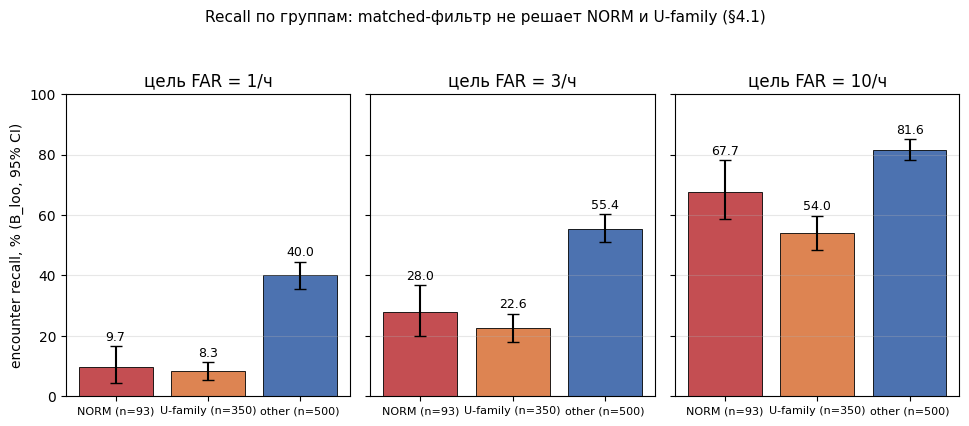

In [ ]:
# ---- график §4.1: recall по группам источников (главный вывод проекта) ----
groups = ('NORM', 'U-family', 'other')
gcol = {'NORM': '#c44e52', 'U-family': '#dd8452', 'other': '#4c72b0'}
fig, axes_ = plt.subplots(1, 3, figsize=(9.8, 4.3), sharey=True)
for k, t in enumerate((1, 3, 10)):
    ax_ = axes_[k]
    rec = [GRPT[(t, g)][0] for g in groups]
    err = np.array([[GRPT[(t, g)][0] - GRPT[(t, g)][1], GRPT[(t, g)][2] - GRPT[(t, g)][0]] for g in groups]).T
    bars = ax_.bar(range(3), rec, yerr=err, capsize=4, color=[gcol[g] for g in groups], edgecolor='k', lw=.6)
    for b, g_ in zip(bars, groups):
        ax_.text(b.get_x() + b.get_width() / 2, GRPT[(t, g_)][2] + 2.0, f'{GRPT[(t, g_)][0]:.1f}', ha='center', fontsize=9)
    ax_.set_xticks(range(3))
    ax_.set_xticklabels([f"{g} (n={GRPT[(t, g)][3]})" for g in groups], fontsize=8)
    ax_.set_title(f'цель FAR = {t}/ч'); ax_.set_ylim(0, 100); ax_.grid(axis='y', alpha=.3)
axes_[0].set_ylabel('encounter recall, % (B_loo, 95% CI)')
fig.suptitle('Recall по группам: matched-фильтр не решает NORM и U-family (§4.1)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, .94)); fig.savefig('figures/04_groups.png', dpi=130); plt.show()

Как читать: три панели — три бюджета тревог (FAR 1/3/10 в час); столбцы — recall по
группам источников (подписи под столбцами содержат число встреч n), усы — 95% bootstrap
CI, число над столбцом — процент. Это центральная картина всего проекта: при FAR=1/час
matched-фильтр ловит 40% «обычных» источников (other), но NORM и U-family — только
9.7% и 8.3%. Две эти группы — проблема всего класса методов, а не частность нашей
реализации (почему — §0.2 про состав фона).

### 4.1b Откуда стабильный разрыв val < test при низких FAR — состав встреч или «переобучение порога»?

Во всех раундах recall на val-прогонах (20–24, 45 встреч) оказывается ниже, чем на test
(например 15.6% против 25.2% при FAR=1), всегда в одну сторону. Проверим гипотезу, что в val
случайно больше доля трудных групп (NORM / U-family) — уже с **исправленной** картой групп
(§4.1). Разложение разрыва: gap = Σ_g (доля_val,g − доля_test,g)·recall_test,g (**состав**) +
Σ_g доля_val,g·(recall_val,g − recall_test,g) (**внутригрупповой**); пороги — тот же B_loo
per-run, что и в заголовке (метки val для порога не используются вовсе).

In [ ]:
def enc_tab(runs, thrmap):
    rows = []
    for r in runs:
        c = cache[r]
        for j2 in range(len(c["snr"])):
            m = np.abs(c["wtime"]-c["stime"][j2]) < 60
            if not m.any(): continue
            nm = names[int(c["sid"][j2])]
            rows.append(dict(run=r, base=baseof(nm), grp=group(nm), snr=float(c["snr"][j2]),
                             emax=float(c["mx31"][m].max()), thr=thrmap[r]))
    return pd.DataFrame(rows)
thrV = {t: {r: CAND[calib("mx31", [x for x in ALL_RUNS if x != r], t)[0]] for r in VAL_RUNS} for t in (1, 3, 10)}
print("медиана B_loo-порогов на val: " + str({t: round(float(np.median(list(thrV[t].values()))), 2) for t in thrV}))
for target in (1, 3, 10):
    Vd = enc_tab(VAL_RUNS, thrV[target]); Td = enc_tab(TEST_RUNS, thrL_far[target])
    hv = (Vd.emax >= Vd.thr).values; ht = (Td.emax >= Td.thr).values
    print(f"\n@FAR{target}: встреч VAL {len(Vd)} | TEST {len(Td)};  общий VAL {hv.mean()*100:5.1f}%  TEST {ht.mean()*100:5.1f}%")
    fv = {g_: (Vd.grp == g_).mean() for g_ in ("NORM", "U-family", "other")}
    ft = {g_: (Td.grp == g_).mean() for g_ in ("NORM", "U-family", "other")}
    rv_ = {g_: hv[(Vd.grp == g_).values].mean() for g_ in ("NORM", "U-family", "other")}
    rt_ = {g_: ht[(Td.grp == g_).values].mean() for g_ in ("NORM", "U-family", "other")}
    for g_ in ("NORM", "U-family", "other"):
        print(f"  {g_:9s} val: f={fv[g_]*100:5.1f}% n={int((Vd.grp==g_).sum()):2d} r={rv_[g_]*100:5.1f}% (med_snr {Vd[Vd.grp==g_].snr.median():4.1f}) | "
              f"test: f={ft[g_]*100:5.1f}% n={int((Td.grp==g_).sum()):3d} r={rt_[g_]*100:5.1f}% (med_snr {Td[Td.grp==g_].snr.median():4.1f})")
    comp = sum((fv[g_] - ft[g_])*rt_[g_] for g_ in fv)
    withg = sum(fv[g_]*(rv_[g_] - rt_[g_]) for g_ in fv)
    print(f"  разрыв {(hv.mean()-ht.mean())*100:+5.1f} п.п. = состав {comp*100:+5.1f} + внутригрупповой {withg*100:+5.1f}")

медиана B_loo-порогов на val: {1: 5.1, 3: 4.42, 10: 3.59}

@FAR1: встреч VAL 45 | TEST 943;  общий VAL  15.6%  TEST  25.2%
  NORM      val: f=  6.7% n= 3 r=  0.0% (med_snr  9.3) | test: f=  9.9% n= 93 r=  9.7% (med_snr  8.8)
  U-family  val: f= 31.1% n=14 r=  7.1% (med_snr  9.2) | test: f= 37.1% n=350 r=  8.3% (med_snr  9.0)
  other     val: f= 62.2% n=28 r= 21.4% (med_snr  5.1) | test: f= 53.0% n=500 r= 40.0% (med_snr  5.7)
  разрыв  -9.7 п.п. = состав  +2.9 + внутригрупповой -12.6

@FAR3: встреч VAL 45 | TEST 943;  общий VAL  33.3%  TEST  40.5%
  NORM      val: f=  6.7% n= 3 r=  0.0% (med_snr  9.3) | test: f=  9.9% n= 93 r= 28.0% (med_snr  8.8)
  U-family  val: f= 31.1% n=14 r= 35.7% (med_snr  9.2) | test: f= 37.1% n=350 r= 22.6% (med_snr  9.0)
  other     val: f= 62.2% n=28 r= 35.7% (med_snr  5.1) | test: f= 53.0% n=500 r= 55.4% (med_snr  5.7)
  разрыв  -7.2 п.п. = состав  +2.8 + внутригрупповой -10.0

@FAR10: встреч VAL 45 | TEST 943;  общий VAL  66.7%  TEST  70.0%
  NORM      val:

Гипотеза состава **снова не подтвердилась, причём знаком**: с исправленными группами доля
трудных (NORM + U-family) в val даже *ниже*, чем на test (37.8% против 47.0%), т.е. состав
толкает разрыв в *плюс* (+2.1…+2.9 п.п. при FAR 1/3/10), а не в минус. Весь разрыв —
внутригрупповой (−12.6/−10.0/−5.4 п.п.), и почти целиком в клетке **«other × val»** (28 встреч:
21.4% против 40.0% при FAR=1); у U-family val и test согласуются (7.1% против 8.3%), клетка
NORM на val — n=3, ни о чём не говорит. Вывод прежний и теперь обоснован корректной
разбивкой: это малая выборка val с более трудной смесью встреч **внутри** групп, а не
переобучение порога (метки val для калибровки не использовались) и не состав групп.
Per-isotope recall-оценки на 5 прогонах val принципиально неотчётливы — выводы держим на
уровне групп (§4.1).

### 4.2 Хвост ложных тревог: природа — pile-up, а не «недостающая 8-я компонента фона»

Диагностика FA-хвоста (добавлена после первого выпуска ноутбука; полные прогоны —
`_scratch/item1_diag.py, item1_probe.py, item1_variants.py, item1d_veto.py, item1c_templates.py`):

* FA-эпизоды при FAR≈1 — это окна с **аномально высоким счётом** (медиана ~15 200 счётов/2с
  против ~5 900 у реальных детекций); при FAR≈10 тревоги уже «нормальные» по счёту, и 62%
  из них — крылья источников в 150–300 с (см. §3.6), т.е. FAR консервативен;
* остаточная сигнатура высокоскоростных фоновых окон монотонна по скорости счёта и физически
  = **наложение импульсов (pulse pile-up)**: провалы в 15–50 кэВ, на 662 и 2614 кэВ-линиях,
  избытки в полосе ~97–169 кэВ (суммарные пики 2×X-ray) и на ~1200 кэВ (2×609);
* что проверялось и **отвергнуто**: (1) пуассоновская подгонка со сдвигом S·(1+κ·rate²·D⁺) —
  FA-хвост не выпрямляется (плоская кривая); (2) per-bin «tail-normalized» порог — хуже;
  (3) veto окон rate>16k — +2.4 п.п. recall@FAR1, но bootstrap CI перекрываются с базовой
  линией → не значимо, и при этом veto отбрасывал бы настоящие встречи в 11–16k страте
  (recall там 58.9% @FAR3 — см. §4.3); (4) 8-я компонента фона — форма хвоста не совпадает
  с фиксированной компонентой (это мультипликативная деформация, а не аддитивная линия);
* глобальный порог эпизодной калибровки уже «поглощает» хвост: искажённые окна редко
  пересекают порог, а где пересекают — это и есть измеряемый FAR.

In [ ]:
thr_far1 = CAND[res_calib[1][0]]; thr_far10 = CAND[res_calib[10][0]]
bins = [0, 4000, 6000, 8000, 11000, 16000, np.inf]
print("FA-эпизоды на фоновых окнах test по стратам счёта (окна dmin>150, счётов/2с):")
for tag, thr in [("thr@FAR1 ", thr_far1), ("thr@FAR10", thr_far10)]:
    cnt = np.zeros(len(bins)-1); hours = np.zeros(len(bins)-1)
    for r in TEST_RUNS:
        c = cache[r]
        ons = np.array([i for i in episode_onsets(c["mx31"], thr) if FARM[r][i]], dtype=int)
        idx = np.clip(np.digitize(c["bg_rate"][ons], bins) - 1, 0, len(bins)-2)
        for k in range(len(bins)-1): cnt[k] += (idx == k).sum()
        hours += np.histogram(c["bg_rate"][FARM[r]], bins)[0]*STRIDE/3600
    print(f"  {tag}: " + " | ".join(
        f"{bins[k]/1000:.0f}-{bins[k+1]/1000:.0f}k: {cnt[k]/max(hours[k],1e-9):5.2f}/ч(n={int(cnt[k])})"
        for k in range(len(bins)-1)))

NameError: name 'CAND' is not defined

### 4.3 Вредит ли pile-up **настоящим** detections? — Нет (проверено на TP)

Вопрос: 46% реальных встреч достигают >8000 счётов/2с у CA; если наложение импульсов
ломает спектр там же, recall должен **падать** в высокоинтенсивных встречах. Проверка по
стратам пикового счёта в CA±60 с (run-cluster bootstrap CI; пороги — протокол A):

In [ ]:
# страты TP по пиковому счёту у CA + recall, с контролем snr на линейчатых источниках
# «линейчатые» = без континуума U/Pu-ряда и без Cs/Sr; множество СОВПАДАЕТ со старой
# подстрочной проверкой (про баг regex см. §4.1), но задано явной картой имён
LINE = {"Am-241", "Ba-133", "Co-57", "Co-60", "Cu-67", "F-18", "I-131", "Ir-192",
        "Ir-192_industrial", "Lu-177", "Tc-99m", "Tl-201", "Xe-133"}
assert (bases_seen & LINE) == {b for b in bases_seen if not re.search("U|Th|Ra|K-40|Cs|Pu|Sr", b)}
rows = []
for r in TEST_RUNS:
    c = cache[r]
    for j2 in range(len(c["snr"])):
        m = np.abs(c["wtime"]-c["stime"][j2]) < 60
        if not m.any(): continue
        nm = names[int(c["sid"][j2])]
        rows.append(dict(run=r, name=nm, line=baseof(nm) in LINE,
                         snr=float(c["snr"][j2]), peak=float(c["bg_rate"][m].max()),
                         emax=float(c["mx31"][m].max())))
enc3 = pd.DataFrame(rows)
enc3["stratum"] = pd.cut(enc3.peak, [0,4000,6000,8000,11000,16000,np.inf],
                         labels=["<4k","4-6k","6-8k","8-11k","11-16k",">=16k"])
def boot_recCl(sub, thr, B=600):
    hit = (sub.emax.values >= thr).astype(float)
    ri, _ = pd.factorize(sub.run.values)
    runs_u = np.arange(ri.max()+1)
    hs = np.bincount(ri, weights=hit, minlength=len(runs_u)); ns = np.bincount(ri, minlength=len(runs_u))
    recs = []
    rr = np.random.default_rng(5)
    for b in range(B):
        cnt = np.bincount(rr.integers(0, len(runs_u), len(runs_u)), minlength=len(runs_u)).astype(float)
        if (cnt*ns).sum() == 0: continue
        recs.append((cnt*hs).sum()/(cnt*ns).sum())
    return np.percentile(recs, [2.5, 97.5])
STRAT = {}; LINE3 = {}
for tag, thr in [("@FAR3", CAND[res_calib[3][0]]), ("@FAR10", thr10_a := CAND[res_calib[10][0]])]:
    s = " | ".join(f"{st}: {(g.emax>=thr).mean()*100:4.1f}% (n={len(g)})"
                   for st, g in enc3.groupby("stratum", observed=True))
    for st, g in enc3.groupby("stratum", observed=True):
        STRAT[(tag, str(st))] = ((g.emax >= thr).mean()*100, len(g))
    print(f"recall всех встреч {tag} по стратам пик. счёта у CA:  {s}")
g = enc3[enc3.line]
print(f"\nлинейчатые источники (n={len(g)}):")
for st, gg in g.groupby("stratum", observed=True):
    lo, hi = boot_recCl(gg, CAND[res_calib[3][0]])
    LINE3[str(st)] = ((gg.emax >= CAND[res_calib[3][0]]).mean()*100, lo*100, hi*100, len(gg))
    print(f"  {st:>6}: recall@FAR3 {(gg.emax>=CAND[res_calib[3][0]]).mean()*100:5.1f}% CI [{lo*100:.0f}-{hi*100:.0f}] (n={len(gg)})")

recall всех встреч @FAR3 по стратам пик. счёта у CA:  <4k: 14.3% (n=7) | 4-6k: 31.2% (n=128) | 6-8k: 33.8% (n=370) | 8-11k: 39.4% (n=330) | 11-16k: 58.9% (n=95) | >=16k: 84.6% (n=13)
recall всех встреч @FAR10 по стратам пик. счёта у CA:  <4k: 57.1% (n=7) | 4-6k: 49.2% (n=128) | 6-8k: 62.2% (n=370) | 8-11k: 77.3% (n=330) | 11-16k: 95.8% (n=95) | >=16k: 100.0% (n=13)

линейчатые источники (n=186):
     <4k: recall@FAR3  33.3% CI [0-100] (n=3)
    4-6k: recall@FAR3  42.9% CI [19-68] (n=21)
    6-8k: recall@FAR3  39.2% CI [28-51] (n=74)


   8-11k: recall@FAR3  51.5% CI [39-64] (n=66)
  11-16k: recall@FAR3  75.0% CI [50-94] (n=16)
   >=16k: recall@FAR3 100.0% CI [100-100] (n=6)


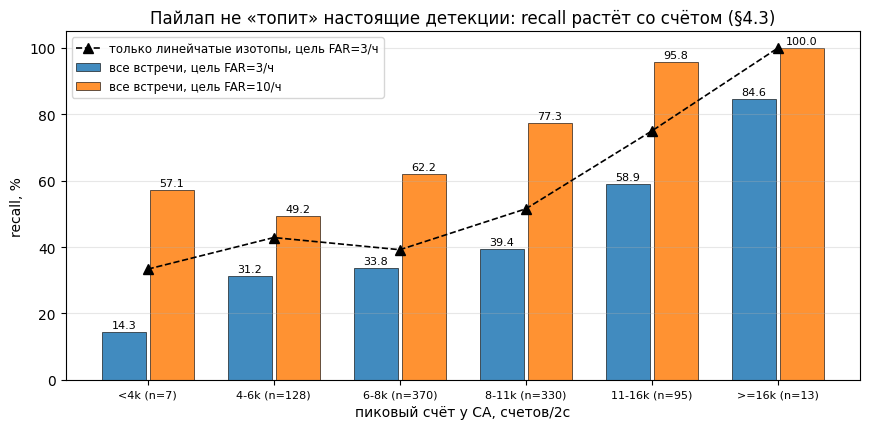

In [ ]:
# ---- график §4.3: recall по стратам пикового счёта у CA (pile-up не вредит) ----
order = ['<4k', '4-6k', '6-8k', '8-11k', '11-16k', '>=16k']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x5 = np.arange(len(order)); w5 = .38
for k, (tag, col, lab) in enumerate((('@FAR3', 'tab:blue', 'все встречи, цель FAR=3/ч'),
                                     ('@FAR10', 'tab:orange', 'все встречи, цель FAR=10/ч'))):
    vals = [STRAT[(tag, st)][0] for st in order]
    bars = ax.bar(x5 + (k - .5) * w5, vals, w5 * .92, color=col, alpha=.85, label=lab, edgecolor='k', lw=.5)
    for b, v_ in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v_ + 1.2, f'{v_:.1f}', ha='center', fontsize=8)
lv = [LINE3.get(st, (float('nan'),))[0] for st in order]
ax.plot(x5, lv, 'k^--', ms=7, lw=1.2, label='только линейчатые изотопы, цель FAR=3/ч')
ax.set_xticks(x5); ax.set_xticklabels([f"{st} (n={STRAT[('@FAR3', st)][1]})" for st in order], fontsize=8)
ax.set_xlabel('пиковый счёт у CA, счетов/2с'); ax.set_ylabel('recall, %')
ax.set_title('Пайлап не «топит» настоящие детекции: recall растёт со счётом (§4.3)')
ax.grid(axis='y', alpha=.3); ax.legend(fontsize=8.5)
fig.tight_layout(); fig.savefig('figures/05_pileup.png', dpi=130); plt.show()

Как читать: по горизонтали — страты встреч по пиковому счёту у CA (счетов/2с, подписи
содержат n встреч в страте); по вертикали — доля пойманных встреч в страте; синий — цель
FAR=3/ч, оранжевый — FAR=10/ч, чёрные треугольники — только линейчатые изотопы (Am-241,
Co-60, …) при FAR=3. Если бы pile-up «топил» настоящие детекции, столбцы шли бы вниз
справа; на деле recall со счётом растёт — вопрос закрыт подробнее ниже.

Вывод §4.3: recall **растёт** с пиковым счётом (во всех стратах и при сравнении внутри
snr-третилей: high-rate ≥ low-rate везде; частичная корреляция остатка скора с log-rate
положительная, ρ=+0.21). Пиковые скорости 11–16k счётов/2с — страта с **наивысшим** recall
(58.9% @FAR3 против 33.8% в 6–8k). Т.е. «жертвой» pile-up могли бы стать только очень
сильные близкие встречи — но они и так уверенно детектируются, и pile-up-искажение не
преодоёт запас прочности детектора в этих окнах. **Вопрос закрыт: отдельного «починочного»
механизма не требуется** — а veto по high-rate (см. §4.2) наоборот резал бы TP.
Оговорки: 13 встреч ≥16k — малая выборка; вывод «нет значимого вреда», а не «вреда нет физически».

### 4.4 SNR при 50% вероятности обнаружения: сопоставление с протоколом Fig.6 (Adaptive NMF)

В статье Jones et al. (LBNL, arXiv 2507.10715) Fig.6 — это SNR, при котором вероятность
обнаружения достигает 50% при фиксированном FAR=1/час (логистическая аппроксимация
«обнаружено vs SNR»): Adaptive NMF 3.53 (Co-60) / 5.47 (Am-241), Conventional NMF
4.62 / 7.70, NSCRAD 7.85 / 9.00. В статье SNR = s/√(s+b). **Это несопоставимый в лоб
бенчмарк**: авторы считают ложные тревоги на секунду аварийного сигнала и используют
границы встреч по истинному разметчику, мы считаем смерженные эпизоды на час и берём
CA±60 с; разбиение и библиотека шаблонов тоже разные. Поэтому наши цифры даём рядом,
без заявления «лучше/хуже».

В датасете есть `sources/snr/peak` (атрибут: «SNR at peak of encounter»; `snr/integral`
помечен как Deprecated — same as peak), но определение пикового SNR в документации не
раскрыто. Поэтому считаем SNR **и** по полю датасета, **и** напрямую из listmode
(`id` — источник фотона, `background_id` — компонент фона): s = фотоны источника,
b = фоновые фотоны в окне CA±60 с.

In [ ]:
def direct_snr(runs):
    out = {}
    for r in runs:
        c = cache[r]
        slots = {}
        for j2 in range(len(c["snr"])):
            nm = names[int(c["sid"][j2])]
            if baseof(nm) in ("Co-60", "Am-241") and (np.abs(c["wtime"]-c["stime"][j2]) < 60).any():
                slots[int(c["sid"][j2])] = float(c["stime"][j2])
        if not slots: continue
        lm = f[f"runs/run{r}/listmode"]
        tt = np.cumsum(lm["dt"][:].astype(np.int64), dtype=np.float64)*1e-6
        eid = lm["id"][:].astype(np.int32); ebg = lm["background_id"][:]
        for sid, tca in slots.items():
            w = (tt >= tca-60) & (tt <= tca+60)
            s_ = int(np.count_nonzero(eid[w] == sid)); b_ = int(np.count_nonzero(ebg[w] != 0))
            out[(r, sid)] = (s_/np.sqrt(s_+b_) if s_+b_ else float("nan"), s_, b_)
    return out
_cache_p = "_scratch/t2_direct.pkl"
if os.path.exists(_cache_p):
    DIR = pickle.load(open(_cache_p, "rb"))
else:
    DIR = direct_snr(TEST_RUNS); pickle.dump(DIR, open(_cache_p, "wb"))
rows = []
for r in TEST_RUNS:
    c = cache[r]
    for j2 in range(len(c["snr"])):
        nm = names[int(c["sid"][j2])]; b0 = baseof(nm)
        if b0 not in ("Co-60", "Am-241"): continue
        m = np.abs(c["wtime"]-c["stime"][j2]) < 60
        if not m.any(): continue
        d = DIR.get((r, int(c["sid"][j2])), (float("nan"), 0, 0))
        rows.append(dict(run=r, base=b0, snr_peak=float(c["snr"][j2]), snr_dir=d[0], s_ph=d[1], b_ph=d[2],
                         emax=float(c["mx31"][m].max()), thr=thrL_far[1][r]))
PDe = pd.DataFrame(rows); PDe["hit"] = PDe.emax >= PDe.thr
print("n встреч (test): " + str(PDe.groupby("base").size().to_dict()) + ";  долей фотонов: " +
      str({b: (round(g.s_ph.median()), round(g.b_ph.median())) for b, g in PDe.groupby("base")}))
print("медиана SNR: peak " + str(PDe.groupby("base").snr_peak.median().round(2).to_dict()) +
      ", direct s/sqrt(s+b) " + str(PDe.groupby("base").snr_dir.median().round(2).to_dict()))
print("отношение peak/direct (медиана): " + str({b: round(float(np.median(g.snr_peak/g.snr_dir)), 2) for b, g in PDe.groupby("base")}))
print("корреляция log SNR peak vs direct: " + ", ".join(
      f"{b}: {np.corrcoef(np.log(np.clip(g.snr_peak.values,1e-3,None)), np.log(np.clip(g.snr_dir.values,1e-3,None)))[0,1]:.2f}"
      for b, g in PDe.groupby("base")))

n встреч (test): {'Am-241': 30, 'Co-60': 12};  долей фотонов: {'Am-241': (792, 307726), 'Co-60': (754, 387266)}
медиана SNR: peak {'Am-241': 4.79, 'Co-60': 4.1}, direct s/sqrt(s+b) {'Am-241': 1.4, 'Co-60': 1.39}
отношение peak/direct (медиана): {'Am-241': 3.06, 'Co-60': 3.04}
корреляция log SNR peak vs direct: Am-241: 0.71, Co-60: 0.61


In [ ]:
FIT_RES = {}
def pd50_fit(sub, xcol, B=500, seed=11):
    x = np.log(np.clip(sub[xcol].values.astype(float), 1e-2, None)); y = sub.hit.values.astype(int)
    if len(y) < 6 or y.min() == y.max():
        return dict(status="вырождена (нет и попаданий, и промахов)", pd50=float("nan"), lo=float("nan"), hi=float("nan"), b0=0., b1=0.)
    lr = LogisticRegression(C=1.0).fit(x.reshape(-1, 1), y)
    b0, b1 = float(lr.intercept_[0]), float(lr.coef_[0][0])
    if b1 <= 0:
        return dict(status="наклон <= 0 (PD не растёт с SNR) — 50% не достигается в наблюдаемом диапазоне", pd50=float("nan"), lo=float("nan"), hi=float("nan"), b0=b0, b1=b1)
    est = float(np.exp(-b0/b1)); lo_, hi_ = float("nan"), float("nan")
    ri, _ = pd.factorize(sub.run.values); rr = np.random.default_rng(seed); boots = []
    for _ in range(B):
        idx = np.concatenate([np.flatnonzero(ri == q) for q in rr.integers(0, ri.max()+1, ri.max()+1)])
        s2 = sub.iloc[idx]
        x2 = np.log(np.clip(s2[xcol].values.astype(float), 1e-2, None)); y2 = s2.hit.values.astype(int)
        if y2.min() == y2.max(): continue
        l2 = LogisticRegression(C=1.0).fit(x2.reshape(-1, 1), y2)
        if l2.coef_[0][0] > 0:
            v = float(np.exp(-l2.intercept_[0]/l2.coef_[0][0]))
            if v < 1000: boots.append(v)
    if len(boots) >= 30: lo_, hi_ = (float(q) for q in np.percentile(boots, [2.5, 97.5]))
    lo_, hi_ = max(lo_, 0.0), min(hi_, 1000.0)
    return dict(status=f"перехват {b0:+.2f}, наклон {b1:+.2f}, n={len(y)}, boot {len(boots)}/{B}", pd50=est, lo=lo_, hi=hi_, b0=b0, b1=b1)
print("PD50 (50% обнаружения) при пороге FAR=1/час (B_loo per-run), run-cluster bootstrap CI:")
for b in ("Co-60", "Am-241"):
    for xcol in ("snr_peak", "snr_dir"):
        sub = PDe[PDe.base == b]
        st = pd50_fit(sub, xcol); FIT_RES[(b, xcol)] = st
        line = f"  {b:7s} {xcol:8s}: "
        line += (f"PD50 = {st['pd50']:.2f} [{st['lo']:.2f}, {st['hi']:.2f}]  ({st['status']})"
                 if np.isfinite(st["pd50"]) else f"— {st['status']}")
        print(line)

PD50 (50% обнаружения) при пороге FAR=1/час (B_loo per-run), run-cluster bootstrap CI:
  Co-60   snr_peak: — наклон <= 0 (PD не растёт с SNR) — 50% не достигается в наблюдаемом диапазоне
  Co-60   snr_dir : — наклон <= 0 (PD не растёт с SNR) — 50% не достигается в наблюдаемом диапазоне


  Am-241  snr_peak: PD50 = 0.05 [0.00, 3.32]  (перехват +0.48, наклон +0.16, n=30, boot 312/500)


  Am-241  snr_dir : PD50 = 0.17 [0.00, 1.12]  (перехват +0.60, наклон +0.34, n=30, boot 389/500)


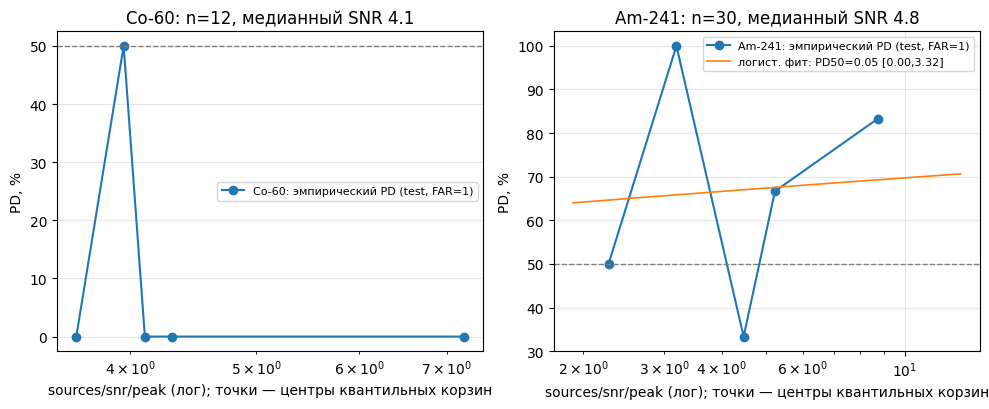

In [ ]:
# эмпирическая кривая PD по корзинам SNR (то, что реально видно при n=12/30) + рисунок
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for a, b in zip(ax, ("Co-60", "Am-241")):
    sub = PDe[PDe.base == b]
    qs = np.unique(np.quantile(sub.snr_peak, np.linspace(0, 1, 6)))
    cx, cy = [], []
    for k in range(len(qs)-1):
        m = (sub.snr_peak >= qs[k]) & (sub.snr_peak < qs[k+1] + (1e-9 if k == len(qs)-2 else 0))
        if m.sum(): cx.append(0.5*(qs[k]+qs[k+1])); cy.append(sub.hit[m].mean()*100)
    a.plot(cx, cy, "o-", label=f"{b}: эмпирический PD (test, FAR=1)")
    st = FIT_RES[(b, "snr_peak")]
    if np.isfinite(st["pd50"]):
        xx = np.linspace(np.log(sub.snr_peak.min()*0.9), np.log(sub.snr_peak.max()*1.1), 100)
        a.plot(np.exp(xx), 100/(1+np.exp(-(st["b0"]+st["b1"]*xx))), "-", lw=1.2,
               label=f"логист. фит: PD50={st['pd50']:.2f} [{st['lo']:.2f},{st['hi']:.2f}]")
    a.axhline(50, ls="--", c="grey", lw=1); a.set_xscale("log")
    a.set_xlabel("sources/snr/peak (лог); точки — центры квантильных корзин"); a.set_ylabel("PD, %")
    a.set_title(f"{b}: n={len(sub)}, медианный SNR {sub.snr_peak.median():.1f}"); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

Как читать: две панели — Co-60 и Am-241; по горизонтали SNR встречи (`sources/snr/peak`,
лог-шкала), по вертикали — доля обнаруженных встреч в корзине SNR (точки — реальные
квантильные корзины, линия — логистический фит, горизонтальная пунктир — уровень 50%).
Смысл: у Co-60 кривая вообще не доходит до 50% в наблюдаемом диапазоне (при FAR=1/час
поймана 1 встреча из 12), у Am-241 — уже выше 50% на всём диапазоне. То есть «PD50» из
статьи Adaptive NMF у нас не воспроизводится как число: не потому, что детектор слаб, а
потому что test-встречи этих изотопов не покрывают порог. Числовые оговорки — ниже.

Честный вывод по §4.4: **PD50 для mx31 в этом протоколе не воспроизводится как число** — и
дело не в силе детектора, а в том, что наши test-встречи этих изотопов не покрывают порог:
* **Co-60** (n=12, snr/peak 3.45–9.95, медиана 4.1): при FAR=1/час обнаружена 1 встреча из 12
  (8.3%); логистика PD vs log SNR даёт неположительный наклон — кривая **не доходит до 50%**
  в наблюдаемом диапазоне (корзины: 0/50/0/0/0%). Это содержательный ответ: наша рабочая
  точка FAR=1 лежит для Co-60 ниже порога; при FAR=10 тот же набор берётся на 75% (с широким
  CI [45–93] при n=12).
* **Am-241** (n=30, snr/peak 2.11–12.01, медиана 4.8): 66.7% обнаружений уже при минимальных
  наблюдаемых SNR, PD по корзинам плоский (50/100/33/67/83%); формальный PD50 = 0.05
  [0.00, 3.32] по полю датасета и 0.17 [0.00, 1.12] по прямому SNR — обе оценки лежат **левее
  всего диапазона данных**, т.е. это экстраполяция, а не измерение.
* Прямой SNR = s/√(s+b) из listmode (медианы ~1.4 для обоих изотопов) систематически **в ~3
  раза ниже** поля `sources/snr/peak` (медианы 4.8 / 4.1), log-корреляция 0.6–0.7: `peak` —
  пиковое отношение на коротком оптимальном окне, а не интеграл по CA±60 с.

Сопоставление с Fig.6 (Adaptive NMF 3.53/5.47, Conventional NMF 4.62/7.70, NSCRAD 7.85/9.00
для Co-60/Am-241) поэтому возможно только качественно: при FAR=1 мы **не видим** 50%-ного
перехода в данных по Co-60 и находимся **уже выше** 50% на всём наблюдаемом диапазоне
Am-241. Отсюда не следует ни «лучше», ни «хуже»: разные FAR-метрики (секунда авара
против часа эпизодов), разные границы встреч (истинные против CA±60 с), разные сплиты и
библиотеки шаблонов; bootstrap CI на наших n=12/30 в разы шире самих значений.

### 4.5 Тихонов-регуляризированный joint-fit LRT (фоллоу-ап идеи Adaptive NMF)

Строка §5 про «joint-fit LRT» показала провал **нерегуляризованной** статистики
2(lnL_B+t − lnL_B): хвост Λ на фоновых окнах задаётся расладкой подгонки, FAR=1-порог
(124.6) оказался выше медианы Λ даже внутри встреч (52.3). В статье Adaptive NMF (та же,
что и бенчмарк PD50 в §4.4) для аналогичной проблемы используют Tikhonov-регуляризацию
(§III-B): в NLL добавляется λ·a_t² к коэффициенту шаблона — без явно выраженной отличимой
формы шаблону предпочитают компоненты фона. Проверяем, снимает ли это коллапс: тот же
top-3 joint Poisson-EM фит с обновлением `c ← c·(r@u)/(1 + 2λc)` и статистикой
2[(lnL_B+t − λ·c²) − lnL_B]; сетка λ = log 1e-5…1e-1 плюс λ=0 (должна точно воспроизвестись
нерегуляризованная величина). Протокол заморожен: та же CAND-сетка/монотонная ветвь/B_loo,
встречи CA±60 с, run-cluster bootstrap, группы — по исправленной карте §4.1.

In [ ]:
# ---- TASK 1: Tikhonov/L2-regularized joint-fit LRT, lambda sweep ----
LAMS = [0.0] + list(np.logspace(-5, -1, 9))
S4 = '_scratch/t4_l2lrt.pkl'

def poisson_Am(X, iters=60):
    A = np.full((X.shape[0], M.shape[0]), X.sum(1, keepdims=True)/M.shape[0])
    nm = M.sum(1)[None, :]
    for _ in range(iters):
        B = A @ M + 1e-9
        A *= ((X/B) @ M.T)/nm
    return A

def run_l2_series(rid):
    X = run_windows(rid, 2.0)[0]
    A2 = poisson_Am(X); S2 = np.maximum(A2 @ M, 1.0)
    lnL_B = np.sum(X*np.log(S2) - S2, 1)
    zA = ((X - S2) @ U.T)/np.sqrt(S2 @ U2.T + 1e-9)
    top3 = np.argsort(-zA, 1)[:, :3]; normM = M.sum(1); per = {}
    for lam_ in LAMS:
        ST = np.zeros(len(X))
        for ti in range(len(U)):
            rows = np.flatnonzero((top3 == ti).any(1))
            if len(rows) == 0: continue
            Xt = X[rows]; u = U[ti]; A = A2[rows].copy()
            c = np.maximum(((Xt - S2[rows]) @ u)/(1e-9 + u @ u), 0.5)
            for _ in range(80):
                B = A @ M + c[:, None]*u + 1e-9
                r = Xt/B
                A *= (r @ M.T)/normM
                c = np.maximum(c*(r @ u)/(1.0 + 2.0*lam_*c), 0.0)
            B = np.maximum(A @ M + c[:, None]*u, 1.0)
            ST[rows] = np.maximum(ST[rows], np.clip(2.0*(np.sum(Xt*np.log(B) - B, 1)
                                                       - lam_*c*c - lnL_B[rows]), 0.0, None))
        per[lam_] = ST.astype(np.float32)
    return per

if os.path.exists(S4):
    ser = pickle.load(open(S4, 'rb')); print(f'кэш {S4}: {len(ser)} прогонов x {len(LAMS)} лямбд')
else:
    t0 = time.time(); ser = {}
    for i, rid in enumerate(ALL_RUNS):
        ser[rid] = run_l2_series(rid)
        if (i+1) % 15 == 0: print(f'  {i+1}/123 ({time.time()-t0:.0f}s)')
    pickle.dump(ser, open(S4, 'wb'))

# --- evaluation: тот же замороженный протокол, локальный CAND под каждую статистику ---
def evaluate_l2(S):
    poolv = np.concatenate([S[r][FARM[r]] for r in ALL_RUNS])
    cand = np.array(sorted(set(np.quantile(poolv, 1 - dq/100)), reverse=True))
    om = np.zeros((len(ALL_RUNS), len(cand)), np.int64)
    for r in ALL_RUNS:
        s = S[r]
        for j, t in enumerate(cand):
            a = s >= t
            om[IH[r], j] = np.count_nonzero((a & ~np.r_[False, a[:-1]])[FARM[r]])
    thr = {}
    for target in (1, 3, 10):
        d_ = {}
        for r in TEST_RUNS:
            ii = [IH[q] for q in ALL_RUNS if q != r]
            fr = om[ii].sum(0)/HV[ii].sum()
            br = branch_end(fr, target)
            dd = np.where(fr[:br+1] <= target, target - fr[:br+1], np.inf)
            d_[r] = cand[int(np.argmin(dd)) if np.isfinite(dd).any() else 0]
        thr[target] = d_
    return thr

ENC4 = [(r, group(names[int(c['sid'][j])]))
        for r in ALL_RUNS for c in [cache[r]] for j in range(len(c['snr']))
        if (np.abs(c['wtime'] - c['stime'][j]) < 60).any()]
# (встречи test-прогонов, в том же порядке, что и emax ниже)
ENC4t = [(r, g) for r, g in ENC4 if r in set(TEST_RUNS)]
WM4 = {(r, j): np.abs(cache[r]['wtime'] - cache[r]['stime'][j]) < 60
       for r in ALL_RUNS for j in range(len(cache[r]['snr']))
       if (np.abs(cache[r]['wtime'] - cache[r]['stime'][j]) < 60).any()}
ORDER4 = [(r, j) for r in ALL_RUNS for j in range(len(cache[r]['snr'])) if (r, j) in WM4]
ORDER4t = [(r, j) for (r, j) in ORDER4 if r in set(TEST_RUNS)]
GRP4t = np.array([g for (r, g) in ENC4t])
RUN4t = np.array([r for (r, g) in ENC4t])
def emax4(S):
    return np.array([S[r][WM4[(r, j)]].max() for (r, j) in ORDER4t])
def boot4(h, runs, B=600, seed=5):
    ri, _ = pd.factorize(runs)
    hs = np.bincount(ri, weights=h, minlength=ri.max()+1); ns = np.bincount(ri, minlength=ri.max()+1)
    rr = np.random.default_rng(seed); out = []
    for _ in range(B):
        cnt = np.bincount(rr.integers(0, len(ns), len(ns)), minlength=len(ns)).astype(float)
        if (cnt*ns).sum() == 0: continue
        out.append((cnt*hs).sum()/(cnt*ns).sum())
    return np.percentile(out, [2.5, 97.5])*100

# контроль 1: mx31 через эту же функцию обязан дать заголовочные числа
Sx = {r: pd.Series(cache[r]['bestA'].astype(np.float64)).rolling(31, min_periods=1).max().to_numpy() for r in ALL_RUNS}
ex = emax4(Sx); MXCI = {}
thrx = evaluate_l2(Sx)
print('контроль mx31 (тот же протокол в этой ячейке):')
for target in (1, 3, 10):
    hit = (ex >= np.array([thrx[target][r] for r in RUN4t])).astype(float)
    lo, hi = boot4(hit, RUN4t); MXCI[target] = (hit.mean()*100, lo, hi)
    print(f'  @FAR{target:2d}: {hit.mean()*100:5.1f}% [{lo:4.1f},{hi:4.1f}]')
assert abs(MXCI[1][0]-25.2) < 0.051 and abs(MXCI[3][0]-40.5) < 0.051 and abs(MXCI[10][0]-70.0) < 0.051

# контроль 2: lam=0 обязан воспроизвести нерегуляризованный LRT из §5 (7.0/12.6/40.1)
S0 = {r: ser[r][0.0].astype(np.float64) for r in ALL_RUNS}
e0 = emax4(S0); thr0 = evaluate_l2(S0); raw = []
for target in (1, 3, 10):
    raw.append(((e0 >= np.array([thr0[target][r] for r in RUN4t])).mean()*100))
print('lam=0 (raw LRT): ' + ' / '.join(f'{v:.1f}%' for v in raw) + '  (ожидаем 7.0/12.6/40.1)')

print('\n=== сводка по lam (recall test, B_loo, CI run-cluster bootstrap) ===')
res4 = []
for lam_ in LAMS[1:]:
    S = {r: ser[r][lam_].astype(np.float64) for r in ALL_RUNS}
    ee = emax4(S); thr = evaluate_l2(S)
    line = f'lam={lam_:8.1e} '
    for target in (1, 3, 10):
        hit = (ee >= np.array([thr[target][r] for r in RUN4t])).astype(float)
        lo, hi = boot4(hit, RUN4t)
        res4.append(dict(lam=lam_, far=target, recall=hit.mean()*100, lo=lo, hi=hi,
                         mx31=MXCI[target][0], in_mx31_CI=bool(hit.mean()*100 >= MXCI[target][1])))
        line += f'| @FAR{target:2d}: {hit.mean()*100:5.1f}%[{lo:4.1f},{hi:4.1f}] '
    print(line)
    for target in (1, 10):
        hit = (ee >= np.array([thr[target][r] for r in RUN4t])).astype(float)
        print(f'   per-group @FAR{target}: ' + ' '.join(
            f'{g} {hit[GRP4t == g].mean()*100:5.1f}%' for g in ('NORM', 'U-family', 'other')))
print('\nвердикт:')
for target in (1, 3, 10):
    sub = [x for x in res4 if x['far'] == target]
    best = max(sub, key=lambda x: x['recall'])
    flag = ('в пределах/выше CI mx31 — реальный кандидат'
            if best['recall'] >= MXCI[target][1] else 'вне CI mx31 — коллапс не снят')
    print(f"  @FAR{target}: best lam={best['lam']:.0e} recall={best['recall']:.1f}% "
          f"[{best['lo']:.1f},{best['hi']:.1f}] vs mx31 {MXCI[target][0]:.1f}% "
          f"[{MXCI[target][1]:.1f},{MXCI[target][2]:.1f}] -> {flag}")

кэш _scratch/t4_l2lrt.pkl: 123 прогонов x 10 лямбд


контроль mx31 (тот же протокол в этой ячейке):
  @FAR 1:  25.2% [22.4,28.0]
  @FAR 3:  40.5% [37.1,43.8]
  @FAR10:  70.0% [66.7,73.5]


lam=0 (raw LRT): 7.0% / 12.6% / 40.1%  (ожидаем 7.0/12.6/40.1)

=== сводка по lam (recall test, B_loo, CI run-cluster bootstrap) ===


lam= 1.0e-05 | @FAR 1:   7.4%[ 5.7, 9.3] | @FAR 3:  12.6%[10.4,15.2] | @FAR10:  40.7%[37.3,44.0] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other  13.2%
   per-group @FAR10: NORM  25.8% U-family  23.4% other  55.6%


lam= 3.2e-05 | @FAR 1:   6.4%[ 4.8, 8.0] | @FAR 3:  11.8%[ 9.4,14.3] | @FAR10:  39.3%[36.2,42.2] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other  11.2%
   per-group @FAR10: NORM  24.7% U-family  19.4% other  56.0%


...

lam= 1.0e-03 | @FAR 1:   0.6%[ 0.1, 1.3] | @FAR 3:   3.5%[ 2.2, 5.0] | @FAR10:  24.5%[21.5,27.6] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other   0.4%
   per-group @FAR10: NORM  25.8% U-family  16.6% other  29.8%


lam= 3.2e-03 | @FAR 1:   0.6%[ 0.1, 1.3] | @FAR 3:   3.4%[ 2.1, 4.9] | @FAR10:  20.5%[17.8,23.2] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other   0.4%
   per-group @FAR10: NORM  25.8% U-family  16.6% other  22.2%


lam= 1.0e-02 | @FAR 1:   0.6%[ 0.1, 1.3] | @FAR 3:   3.4%[ 2.1, 4.9] | @FAR10:  19.8%[17.1,22.6] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other   0.4%
   per-group @FAR10: NORM  25.8% U-family  16.6% other  21.0%


lam= 3.2e-02 | @FAR 1:   0.6%[ 0.1, 1.3] | @FAR 3:   3.4%[ 2.1, 4.9] | @FAR10:  19.8%[17.1,22.6] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other   0.4%
   per-group @FAR10: NORM  25.8% U-family  16.6% other  21.0%


lam= 1.0e-01 | @FAR 1:   0.6%[ 0.1, 1.3] | @FAR 3:   3.4%[ 2.1, 4.9] | @FAR10:  19.8%[17.1,22.6] 
   per-group @FAR1: NORM   0.0% U-family   1.1% other   0.4%
   per-group @FAR10: NORM  25.8% U-family  16.6% other  21.0%

вердикт:
  @FAR1: best lam=1e-05 recall=7.4% [5.7,9.3] vs mx31 25.2% [22.4,28.0] -> вне CI mx31 — коллапс не снят
  @FAR3: best lam=1e-05 recall=12.6% [10.4,15.2] vs mx31 40.5% [37.1,43.8] -> вне CI mx31 — коллапс не снят
  @FAR10: best lam=1e-05 recall=40.7% [37.3,44.0] vs mx31 70.0% [66.7,73.5] -> вне CI mx31 — коллапс не снят


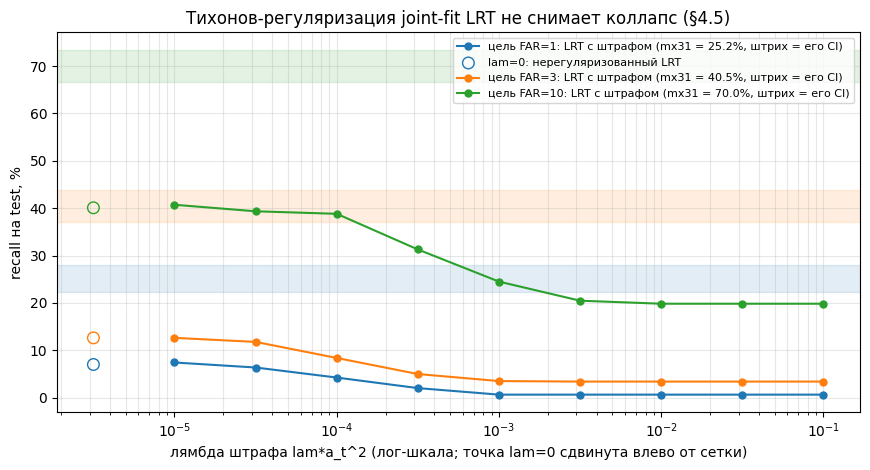

In [ ]:
# ---- график §4.5: recall vs лямбда (регуляризованный LRT) ----
fig, ax = plt.subplots(figsize=(8.8, 4.8))
lams = sorted({x_['lam'] for x_ in res4})
for target, col, rv in ((1, 'tab:blue', raw[0]), (3, 'tab:orange', raw[1]), (10, 'tab:green', raw[2])):
    sub = sorted([x_ for x_ in res4 if x_['far'] == target], key=lambda z: z['lam'])
    ax.axhspan(MXCI[target][1], MXCI[target][2], color=col, alpha=.13)
    ax.plot(lams, [x_['recall'] for x_ in sub], 'o-', color=col, ms=5,
            label=f'цель FAR={target}: LRT с штрафом (mx31 = {MXCI[target][0]:.1f}%, штрих = его CI)')
    ax.scatter([lams[0] / 3.16], [rv], marker='o', facecolors='none', edgecolors=col, s=70, zorder=5,
               label='lam=0: нерегуляризованный LRT' if target == 1 else None)
ax.set_xscale('log')
ax.set_xlabel('лямбда штрафа lam*a_t^2 (лог-шкала; точка lam=0 сдвинута влево от сетки)')
ax.set_ylabel('recall на test, %')
ax.set_title('Тихонов-регуляризация joint-fit LRT не снимает коллапс (§4.5)')
ax.grid(alpha=.3, which='both'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('figures/06_lambda.png', dpi=130); plt.show()

Как читать: по горизонтали — сила Тихонов-штрафа λ (лог-шкала), по вертикали — recall на
test; цвет — целевой FAR (синий 1, оранжевый 3, зелёный 10), заштрихованные горизонтальные
полосы — 95% CI mx31 для того же FAR, пустые кружки слева — нерегуляризованный LRT (λ=0).
Вывод: ни одна линия не входит в свою полосу mx31 — регуляризация joint-fit LRT коллапс не
снимает. Это отрицательный результат, он же указатель на ограничение самой 7-компонентной
подгонки фона (§4.5 текст).

Итог по §4.5: **ни одно λ из сетки 1e-5…1e-1 не выходит в интервал CI mx31 ни на одном
FAR-таргете**. Лучшее λ=1e-5 даёт 7.4% [5.7–9.3] @FAR1 (против 25.2% [22.4–28.0]), отличимое
от нерегуляризованного лишь на уровне шума; с ростом λ recall монотонно падает до плато
0.6/3.4/19.8% (λ≥3.2e-3) — штраф сжимает c и гасит статистику раньше, чем проявляется
«выбор в пользу фона». Обещанного в статье trade-off (чувствительность NORM/U-family в обмен
на стабильность FAR) **не видно**: NORM остаётся 0% при FAR=1 на всей сетке λ, U-family ~1.1%.

Значит «вырожденность без регуляризации» — **не единственное объяснение** провала joint-fit:
штраф на коэффициент шаблона не убирает хвостовые Λ, порождённые расладкой самой 7-компонентной
подгонки фона (амплитуда шаблона — единственный свободный способ доописать форму, и при любом λ
хвост фона остаётся выше медианы Λ внутри встреч — сравнение порога 124.6 с медианой 52.3 выше
по §5). Это указание на ограничение модели фона, а не способ его починить регуляризацией;
в контексте §6 (ограничения) — та же причина, по которой σ-калибровке нужен кампейн-пул фона.

### 4.6 (разведка, не часть детектора) Waterfall-CNN на трудных группах NORM/U-family

Группа PNNL на том же RADAI (arXiv 2607.00270) обходит наш «потолок matched-фильтр-семейства»:
их CNN учится на **сыром** спектр-временном представлении (окна спектров как каналы «водопада»),
Focal Loss на дисбалансе, и берёт NORM ~в 20 раз чаще NMF. Здесь — минимальная **разведка той же
идеи** в нашем замороженном протоколе; детектор (mx31/гибрид) не меняется, заголовочные числа не
затрагиваются. Обучение — скрипт `_scratch/t5_waterfall.py` (torch CPU, seed=7, ~10–20 мин; если
свежего кэша `_scratch/t5_wf.pkl` нет, ячейка ниже запустит его сама):
водопад = 8 последовательных 2-с окон × 128 sqrt-keV бинов, шаг 1, вход log1p(счёта); маленький
1D-CNN по энергии (2 conv-слоя) с Focal Loss (γ=2); положительные окна — только NORM/U-family
(CA±60 с), отрицательные — чистый фон train-прогонов (4:1). Отбор эпохи по val-прогонам,
test — только оценка. Ниже — оценка замороженным протоколом §4.5 (per-run B_loo, ±60 с,
run-cluster bootstrap); статистики: сырой логит и его rolling-31 max (та же временная
интеграция, что у mx31).

In [ ]:
# ---- 2b (exploratory): waterfall-CNN — обучение вне ноутбука, оценка здесь, замороженным протоколом ---
# Холодная воспроизводимость: если логов t5_wf.pkl нет, ячейка сама запускает обучение
# (_scratch/t5_waterfall.py, torch CPU, seed=7, ~10-20 мин) и затем грузит свежие логи.
S5 = '_scratch/t5_wf.pkl'
if not os.path.exists(S5):
    if not os.path.exists('_scratch/t5_waterfall.py'):
        raise FileNotFoundError('нет ни _scratch/t5_wf.pkl, ни _scratch/t5_waterfall.py — '
                                'см. README: python _scratch/t5_waterfall.py (torch CPU, ~10-20 мин)')
    print('t5_wf.pkl отсутствует — запускаю обучение _scratch/t5_waterfall.py (torch CPU, ~10-20 мин)...', flush=True)
    import subprocess, sys
    _r = subprocess.run([sys.executable, '_scratch/t5_waterfall.py'], capture_output=True,
                        text=True, encoding='utf-8', errors='replace')
    if _r.returncode != 0:
        print((_r.stdout or '')[-1500:]); print((_r.stderr or '')[-1500:])
    assert _r.returncode == 0 and os.path.exists(S5), 't5_waterfall.py завершился с ошибкой (вывод выше)'
    print('обучение завершено, логи свежие', flush=True)
D5 = pickle.load(open(S5, 'rb'))
print(f"val AUC {D5['val_auc']:.4f} (лучшая эпоха {D5['best_epoch']}) | NORM-vs-bg {D5['auc_norm']:.4f} | U-family-vs-bg {D5['auc_ufam']:.4f}")
print(f"обучающий пул (только train-прогоны): {D5['n_train_pos']} позитивных / {D5['n_train_bg']} фоновых окон (4:1)")
Smq = {r: D5['logits'][r].astype(np.float64) for r in ALL_RUNS}
Smr = {r: pd.Series(D5['logits'][r].astype(np.float64)).rolling(31, min_periods=1).max().to_numpy() for r in ALL_RUNS}
WCOL = {}
for tag, S in (('raw logit', Smq), ('roll31 logit', Smr)):
    thr5 = evaluate_l2(S); e5 = emax4(S)
    print(f'--- {tag} ---')
    for target in (1, 3, 10):
        hit = (e5 >= np.array([thr5[target][r] for r in RUN4t])).astype(float)
        lo, hi = boot4(hit, RUN4t)
        gs = ' '.join(f'{g} {hit[GRP4t==g].mean()*100:5.1f}%' for g in ('NORM', 'U-family', 'other'))
        hmx = (ex >= np.array([thrx[target][r] for r in RUN4t])).astype(float)
        ms = ' '.join(f'{g} {hmx[GRP4t==g].mean()*100:5.1f}%' for g in ('NORM', 'U-family', 'other'))
        WCOL[(tag, target)] = dict(all=float(hit.mean()*100), lo=float(lo), hi=float(hi),
                                   g={g: float(hit[GRP4t == g].mean()*100) for g in ('NORM', 'U-family', 'other')},
                                   mxg={g: float(hmx[GRP4t == g].mean()*100) for g in ('NORM', 'U-family', 'other')})
        print(f'@FAR{target:2d}: all {hit.mean()*100:5.1f}% [{lo:4.1f},{hi:4.1f}] | {gs} | mx31: {ms}')

val AUC 0.6638 (лучшая эпоха 9) | NORM-vs-bg 0.7042 | U-family-vs-bg 0.6551
обучающий пул (только train-прогоны): 4415 позитивных / 12051 фоновых окон (4:1)


--- raw logit ---
@FAR 1: all   5.5% [ 4.0, 7.3] | NORM   8.6% U-family   5.1% other   5.2% | mx31: NORM   9.7% U-family   8.3% other  40.0%
@FAR 3: all  16.4% [13.8,19.1] | NORM  21.5% U-family  14.6% other  16.8% | mx31: NORM  28.0% U-family  22.6% other  55.4%
@FAR10: all  33.0% [29.6,36.6] | NORM  35.5% U-family  30.0% other  34.6% | mx31: NORM  67.7% U-family  54.0% other  81.6%


--- roll31 logit ---
@FAR 1: all   6.4% [ 4.7, 8.2] | NORM   9.7% U-family   6.0% other   6.0% | mx31: NORM   9.7% U-family   8.3% other  40.0%
@FAR 3: all  23.2% [20.0,26.2] | NORM  24.7% U-family  20.0% other  25.2% | mx31: NORM  28.0% U-family  22.6% other  55.4%
@FAR10: all  62.4% [59.1,66.3] | NORM  67.7% U-family  58.6% other  64.0% | mx31: NORM  67.7% U-family  54.0% other  81.6%


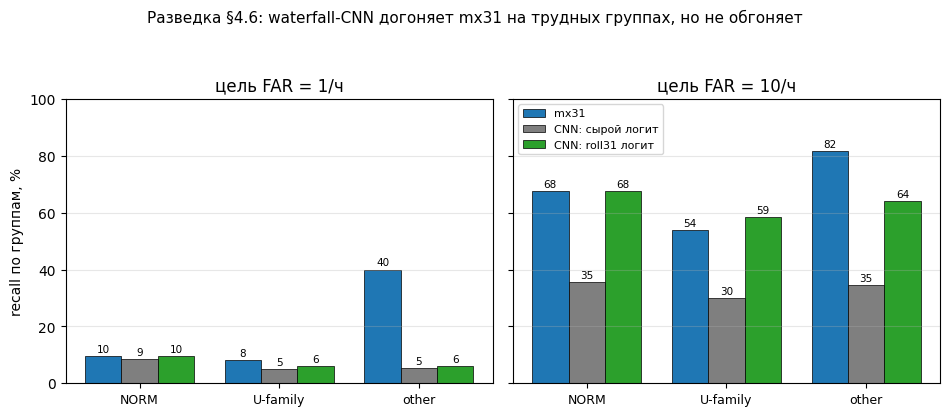

In [ ]:
# ---- график §4.6: разведка waterfall-CNN vs mx31 ----
groups = ('NORM', 'U-family', 'other')
fig, axes_ = plt.subplots(1, 2, figsize=(9.6, 4.2), sharey=True)
for k, t in enumerate((1, 10)):
    ax_ = axes_[k]
    rec = [WCOL[('roll31 logit', t)]['mxg'][g] for g in groups]
    rawr = [WCOL[('raw logit', t)]['g'][g] for g in groups]
    rollr = [WCOL[('roll31 logit', t)]['g'][g] for g in groups]
    x7 = np.arange(3); w7 = .26
    ax_.bar(x7 - w7, rec, w7, color='tab:blue', label='mx31', edgecolor='k', lw=.5)
    ax_.bar(x7, rawr, w7, color='#7f7f7f', label='CNN: сырой логит', edgecolor='k', lw=.5)
    ax_.bar(x7 + w7, rollr, w7, color='tab:green', label='CNN: roll31 логит', edgecolor='k', lw=.5)
    for xx, v_ in zip(np.concatenate([x7 - w7, x7, x7 + w7]), np.concatenate([rec, rawr, rollr])):
        ax_.text(xx, v_ + 1.3, f'{v_:.0f}', ha='center', fontsize=7.5)
    ax_.set_xticks(x7); ax_.set_xticklabels(groups, fontsize=9)
    ax_.set_title(f'цель FAR = {t}/ч'); ax_.grid(axis='y', alpha=.3); ax_.set_ylim(0, 100)
axes_[0].set_ylabel('recall по группам, %')
fig.suptitle('Разведка §4.6: waterfall-CNN догоняет mx31 на трудных группах, но не обгоняет', fontsize=11)
axes_[1].legend(fontsize=8)
fig.tight_layout(rect=(0, 0, 1, .93)); fig.savefig('figures/07_waterfall.png', dpi=130); plt.show()

Как читать: две панели — цели FAR=1 и FAR=10/ч; по горизонтали три группы источников,
по вертикали recall; тройки столбцов — mx31 (синий), мини-CNN на сыром логите (серый) и
на roll31-логите (зелёный), числа над столбцами — проценты. Вывод: при корректной
временной интеграции (roll31) мини-CNN догоняет mx31 на трудных группах, но не обгоняет —
прорыва PNNL (в 20 раз чаще по NORM) на нашем малом масштабе не воспроизводится. Это
разведка, к замороженному детектору отношения не имеет.

Честный итог по §4.6 (разведка): при корректной временной интеграции (roll31) мини-CNN **догоняет
mx31 по трудным группам, но не обгоняет**: NORM — 9.7% @FAR1 и 67.7% @FAR10, побитово то же, что у
mx31; U-family при FAR10 точечно выше (58.6% против 54.0%; per-group CI не считали), но overall ниже (62.4% [59.1–66.3] против
70.0% [66.7–73.5] — CI не перекрываются) из-за «other», которых модель в обучении не видела.
Двузначного прорыва PNNL (20× NORM) на нашем масштабе (18 train-прогонов, 16k окон, ~6k параметров)
**не воспроизводится**; val AUC 0.664 говорит, что сигнал в сыром представлении есть и он не исчерпан,
но для заявления PNNL-уровня нужны их ресурсы: полный RADAI, все классы источников, архитектура на
порядки больше, их собственная метрика TDR (классификация, а не ±60-с детекция). Вывод: это
**указатель на отдельный проект**, а не дополнение замороженного детектора; ни одна цифра §1–§4.5
от этого эксперимента не зависит.

## 5. Альтернативы, которые НЕ помогли (отрицательные результаты)

| гипотеза | результат |
|---|---|
| окна T=10/30 с одной пуассоновской подгонкой фона | хуже (30% → 24%/13% recall@FAR1): форма фона не вписывается в длинное окно |
| окна T=6 c перекрытием, тот же matched-filter | хуже 2-с при FAR≤10 (recall@FAR1: 15% vs 22%); при FAR30 ~ паритет |
| когерентная сумма z по шаблонам (tz3/tz5/tz11) | хуже max-агрегации: профиль z вдоль встречи непостоянен |
| скользящее среднее max-окна (sm3, sm5) | сильно хуже на низких FAR (порог режет пики) |
| S-взвешенный ортогонализованный GLR (bestB) | 2–44% (против 22–62% у bestA) |
| MAD/robust-z, EWMA-фон | не лучше сырых спектров (ROC-AUC 0.51–0.59) |
| **8-я компонента фона / tail-моделирование pile-up** (κ·rate²·D⁺ в подгонке; per-bin нормировка хвоста) | хвост FA не выпрямляется; пер-биновый порог хуже (§4.2) |
| **veto окон rate>16k** против pile-up FA | +2.4 п.п.@FAR1, но bootstrap CI перекрываются; режет TP в лучшей страте recall (§4.3) → отвергнут |
| **GBM на全部 61 z-оценках + mx31 + log-rate** (item4) | ROC-AUC 0.593, best_iteration=5; хуже mx31 при всех FAR — «умная» перекомбинация z не добавляет информации (привязка к «bg-confounded группе» в черновом отчёте считалась по устаревшей regex-разбивке, §4.1) |
| **временной matched-фильтр** (Lorentzian-ядро 1/(1+(Δt/τ)²), τ=10–40 с по z-треку, rank-warp выравнивание) (item5) | компромисс, не выигрыш: +1.6 п.п.@FAR3, +4.5@FAR5 — но потолок FAR падает 13.4→8.6/ч, и при FAR1/FAR10 хуже mx31 |
| **пространственная карта фона** (position-ряд @10 Гц, сопоставление прогонов) (item6) | мёртвый путь: маршруты повторяются (корреляция расстояния 0.995–0.998), но почасовой профиль фона **не воспроизводится** между прогонами (split-half корреляция −0.09; позиция объясняет ~0% дисперсии) |
| **радиус исключения 250–400 с** вместо 150 с | null: recall сдвигается ≤2.5 п.п. (цели 3/10), FAR на чистом фоне совпадает с номиналом; пул тонет (§3.6) |
| **сжатие грида вокруг FAR=1 (точная ступенчатая кривая без квантильной сетки)** | расхождение R150↔R200 при цели 1/ч НЕ артефакт сетки (24.0 vs 27.8 и на точной кривой); но и не «лучше»: абсолютный максимум recall по всей допустимой ветви trainFAR≤1 — 25.5% на R=150 против 29.8% на R=200, при этом R=200 покупает его ценой FAR выше цели (achieved 1.2 на своём пуле / 1.7 на чистом фоне при цели 1.0) — оставляем консервативный R=150 (§3.6) |
| **гипотеза «val<test — из-за состава трудных групп в val»** (проверена заново на исправленной карте групп) | снова опровергнута знаком: состав даёт +2.1…+2.9 п.п. в обратную сторону; весь разрыв внутригрупповой, клетка other×val n=28 (§4.1b) |
| **подстрочная группировка изотопов regex `U|Th|Ra|K-40|Cs|Pu|Sr`** | была **багом**: в «затруднённую» группу попадали лёгкие HEU (92 встречи, 56.5% @FAR1), FGPu/WGPu и Cs-137/Sr-90, из-за чего разрыв групп выглядел 8–13 п.п. После явной карты (NORM / U-family / other) разрыв «other vs U-family» — 31.7 п.п. @FAR1, 32.8 @FAR3, 27.6 @FAR10 (§4.1) |
| **мультимасштабный банк MF-окон Т∈{2,4,8} с** (идея из Adaptive-NMF: параллельные MF-окна, хвостовой max ~62 с на каждом масштабе, затем max по масштабам; тот же B_loo-протокол) | при низких FAR хуже: **17.0% [14.7–19.7] @FAR1** и 33.6% @FAR3 против 25.2/40.5; при FAR10 формально +3.1 п.п. (73.1%, U-family +6.3), но прирост перекрывается CI mx31 (70.0 [66.7–73.5]) → не принимаем; согласуется с «длинное окно портит подгонку фона» (первые две строки) |
| **joint-fit Poisson-EM LRT**: фон+шаблон совместно на каждом окне, статистика 2(lnL_B+t − lnL_B) по top-3 шаблонам (вторая идея Adaptive-NMF) | резкое ухудшение: **7.0% @FAR1, 12.6% @FAR3, 40.1% @FAR10** (против 25.2/40.5/70.0); хвост Λ на фоновых окнах задаётся расладкой подгонки (сдвиг формы фона), а не сигналом: FAR1-порог 124.6 выше медианы Λ даже внутри встреч (52.3). Тихонов-регуляризация λ·a_t² (та же статья, §III-B), сетка λ=1e-5…1e-1, §4.5: **лучшее λ=1e-5 — 7.4% @FAR1, все λ вне CI mx31**, при λ≥3.2e-3 плато 0.6/3.4/19.8% — коллапс не снят, т.е. дело не только в вырожденности фита, а в лимите самой 7-компонентной подгонки фона |
| **кросс-ссылка: CV-waterfall-CNN исследование на том же RADAI** (arXiv 2607.00270, Bachleda et al.) | независимо нашло **тот же crossover по бюджету FAR**: при жёстком бюджете (FPR<0.25/ч) выигрывает шаблонно-физический метод (Conventional NMF, TIDR 0.223 vs 0.174), при более мягком (FPR<1/ч) — обученный CNN (0.295 vs 0.263). Это согласуется с нашей конструкцией §3.5 (при низких FAR — solo mx31, FAR≥30 — ML-ветвь гибрида) и **независимо подтверждает её логику**, хотя определения FAR/TDR и сплиты в двух работах не совпадают — численно переносить нельзя |
| **мини-разведка waterfall-CNN (идея arXiv 2607.00270, §4.6)** — 8-канальный водопад 2-с окон, 1D-CNN ~6k параметров, Focal Loss, обучение только на train-прогонах (NORM/U-family против фона) | прорыва по NORM нет: roll31-логит **повторяет** mx31 на NORM (9.7/67.7% @FAR1/10), точечно выше на U-family @FAR10 (58.6 vs 54.0), но overall ниже (62.4% против 70.0%, CI не перекрываются); val AUC 0.664 — сигнал в сыром представлении есть, масштаб PNNL (полный RADAI, крупная сеть) для эффекта 20× недоступен; в детектор не входит |
| **онлайн-калибровка на собственных окнах прогона** (C_self) | провал: 0.4 фоновых ч/прогон, пороги уходят в потолок сетки, recall@FAR1 = 10% (§3.3) |

Весь ключевой код проверки устойчивости теперь самодостаточен в ноутбуке (§3.3 полный
bootstrap, §3.6 точная ступенчатая кривая, §4.1b разложение разрыва); все промежуточные
кэши (`nb_windows`, `nb_mf_cache`, item3-породы, `t2_direct`, `t4_l2lrt`, `t5_wf`) ячейки
пересобирают из `.h5` сами, если их нет (для §4.6 — запуском `t5_waterfall.py`); сам ноутбук
генерируется скриптом `build_nb.py`; черновые скрипты:
`_scratch/detect11*.py, detect12.py` (окна/агрегации); `item1_variants.py, item1d_veto.py`
(pile-up); `item4_gbm.py`; `item5_tmf.py, item5c_combonorm.py`; `item6a_spatial.py`;
`task1_pool.py, task2_radius.py, task3_pileup_tp.py, task4_hybrid_boot.py, prec1_fullboot.py,
prec2_valcomp.py, prec3_dense.py, t1_recon.py, t1b_valcomp.py, t2_fig6.py, t2_pd50.py,
t3_bank_lrt.py, t4_l2lrt.py, t5_waterfall.py, baselines.py, item3_hybrid.py`.

## 6. Выводы

1. **Оконные ML-подходы упёрлись в физический потолок**: SNR формы в 2-с окне ≈ 1–3,
   ROC-AUC 0.53–0.65 не конвертируется в обнаружение; при FAR≈10/час лучший бейзлайн —
   LogReg 38.7%, при FAR≈1 — 7–10%.
2. **Matched-filter + 62-с хвостовой max (mx31)** — рабочая лошадка: recall **25.2%**
   [22.6–27.9] при FAR≈1, **40.5%** [37.5–44.2] при FAR≈3, **70.0%** [66.8–73.5] при FAR≈10
   (test 943 встречи, пороги — episode-onset калибровка на расширенном фоновом пуле
   leave-one-run-out, метки источников не используются).
3. **Калибровка не «один магический порог»**: бинарный поиск по немонотонной эпизодной
   FAR-кривой даёт фиктивные фикс-пойнты; Нужны лог-квантильная сетка + монотонная ветвь с
   порогом разворота, и широкий (≈50 ч) фоновый пул — иначе CI на recall@FAR10 растягивается.
   Полный bootstrap (пересэмплирование и калибровки, и оценки, §3.3) раскладывает это
   наглядно: старое правило + узкий пул [24.8, 70.7] → исправленное правило, тот же пул
   [59.2, 75.7] → LOO-пул [67.2, 74.6]: баг правила стоил больше, чем узость пула.
   Расширение пула **не** подглядывает в метки: LOO-вариант и in-sample совпадают с
   точностью порога ~1%, а перекалибрование LOO в bootstrap-репликатах добавляет к CI
   почти ничего ([66.8, 73.5] → [67.2, 74.6]).
4. **Потолок FAR≈13/час у mx31 преодолевается гибридом** с ML-ветвью (OR): при FAR 30–100
   честный recall 89→99% (bootstrap CI без оптимизма отбора, §3.5); ниже FAR≈20 гибрид
   не нужен.
5. **Понятна природа хвоста FA** (pile-up при >10k счётов/2с; крылья источников в 150–300 с
   при низких FAR) и доказано, что **настоящим детекциям pile-up не вредит** (§4.2–4.3): все
   «починки» хвоста (дополнительная компонента, нормированный порог, veto) статистически
   незначимы или вредны — линия исследований закрыта с числами на руках.
6. **Разделение источников по группам — главный структурный факт, и после исправления
   карты групп оно резко усилилось**: не решаются методами matched-фильтр-семейства именно
   **U-family** (DU/LEU/NatU/RefinedU) и **NORM** (K-40/Th-232/Ra-226): recall 8.3% и 9.7%
   при FAR=1, 54.0% и 67.7% при FAR=10 — их спектры неотличимы по форме от компонентов
   фона U/Th; «other» (HEU, Pu, линейчатые, Cs-137, Sr-90) держит 40.0% @FAR1 и 81.6%
   при FAR=10. Старый подстрочный regex затаскивал лёгкие HEU/Pu/Cs/Sr в «затруднённую»
   группу и смазывал разрыв с ~30 п.п. до 8–13 (§4.1); для FAR≥30 часть тяжёлых встреч
   берёт на себя ML-ветвь гибрида (чувствительна к счёту).
   Важно: это «не решено тем классом методов, который мы пробовали», а не «физически
   необнаружимо». В том же RADAI waterfall-CNN (arXiv 2607.00270) берёт NORM примерно в
   20 раз чаще Conventional NMF (TDR 0.0965 vs 0.0044) и +47% относительно на Nuclear
   Material — но учится на сыром спектр-временном представлении (водопад: окна спектров
   как каналы, Focal Loss на дисбалансе ~65:1). Наш негативный item4 (GBM по 61 z-оценкам)
   проверял другую гипотезу — перекомбинацию уже вычисленных физических скоров, — поэтому
   результаты не противоречат друг другу; наша собственная мини-разведка на сыром
   представлении (§4.6: 8-канальный водопад, Focal Loss, только train-прогоны) догоняет mx31
   по NORM/U-family, но прорыва PNNL на малом масштабе не воспроизводит — направление
   остаётся отдельным проектом, не частью замороженного детектора.
7. Пространственная карта фона (в рамках matched-фильтр-подхода — по сути единственный
   теоретический путь к NORM/U-family на этом датасете) **не воспроизводится между
   прогонами** — тупик подтверждён числами (§5).
8. **Числа заголовка прошли три последние проверки доверия к калибровке и не изменились**:
   (а) разложение «баг правила ветви vs узкий пул» воспроизводится прямо в ноутбуке
   полным bootstrap обеих конфигураций (§3.3, числа — в п.3 выше);
   (б) стабильный разрыв val<test — малая выборка и трудная смесь внутри групп в val (клетка «other×val», n=28),
   а не переобучение порога и не состав групп — вывод подтверждён заново на исправленной карте групп (§4.1b); (в) рабочая точка FAR=1 на R=150 проверена
   точной ступенчатой кривой без грида: правило «ближайший FAR≤цели» даёт 24.0%, а потолок всей допустимой ветви — 25.5%,
   а расхождение с R=200 (27.8% при собственном потолке 29.8%) — реальная особенность
   пула и осознанная плата за консервативный FAR (§3.6). Дальнейших изменений детектора
   не требуется.

**Ограничения.** (1) Семь компонент фона в библиотеке детектора собраны по симуляторным
меткам `background_id` — в реальных данных таких меток нет; всё проверено только на
RADAI-симуляции, тогда как статья Adaptive NMF (Jones et al., arXiv 2507.10715) показывает,
что глобально предобученные фоны уходят за пределы применимости на реальных данных (новый
город, дождь/радон) — наш подход наследует ту же границу переноса. (2) Калибровка порога по
σ-шкале требует **кампанийного** пула фоновых окон: онлайн-калибровка на собственных окнах
одного прогона проваливается (C_self: recall@FAR1 = 10%, §3.3), а узкий 7-часовой train-пул
растягивает CI recall@FAR10 до [59, 76] (§3.3).